In [1]:
import numpy as np
import pandas as pd
# import math

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import h5py
import json
import matplotlib 
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.signal import hilbert, savgol_filter
from scipy.optimize import curve_fit
from scipy.linalg import expm

import os
import sys  
import warnings

from ast import literal_eval

from qutip import  *

sys.path.append('../../scripts') 

from qutip_tools import *

In [2]:
# define basic figure sizes
bwidth=7    
bheight=5
base_font = 20

matplotlib.rcParams.update({'font.size': base_font,"legend.fontsize":base_font-4 ,"font.family": "serif", 
                            "font.serif": "CMU Serif, Times New Roman",
                           'text.usetex' : True })

sns.set_palette("colorblind")

fig_route = "../../plots/synthetize/"

ll=100
J=1
a = 1 # lattice spacing
data_route = "../../data/exact_diag_new/L={}/".format(ll)




# Functions

In [3]:

def get_transmision_proba(gt, K0, Δ):
    # calculate the transmision coefficient for the QPC wavepacket
    # gt = the interaction strength
    # momentum for the integration
    k_arr = np.linspace(-100, 100, 5000)
    m = 1/(2*J**2) # effective mass for the quadratic dispersion

    Psi0k_abs = (Δ ** 2 / np.pi)**(1/2) * np.exp(-Δ**2*(k_arr - K0)** 2 )
    # now with the wave packet weights
    T_k = 1 / (1 + (m*gt / k_arr)** 2)
    T_tot = simpson(T_k * Psi0k_abs, dx=k_arr[1] - k_arr[0])

    return T_tot

def get_qubit_occupations(ρ_list):
    # apply the density opperator to the qubit denisty matrices and return the occupations
    occ_list = []
    # create density operator for the 0th qubit state 
    ketbra = np.outer([1,0], np.conj([1,0]))
    for ρ in ρ_list:
        occ =  np.real(np.trace(ketbra @ ρ))
        occ_list.append(occ)
    return np.asarray(occ_list)

def evolve_q(ρ0 , times, H_qubit):
    # tho0 is the initial denisty matrix of the qubit
    #  times is the array with the time points we evolve to
    ρt = []
    for t in times:
        U = expm(-1j*H_qubit*t)
        ρt.append(U @ ρ0 @ U.conj().T)
    return np.array(ρt)

def extend_qubit_occupations(ρ0, t_init ,d0_density ,times, num_osc=2):
    # evolve the qubit density matrix with the free hamiltonian for a longer time to get the occupations
    # here \rho0 is the last density matrix of the simulated dynamics which we use as initial state
    # first lets extend the range of oscillations of the qubit by applying the independent dynamics as a unitary on the density matrix
    Hqubit = np.zeros((2,2), dtype=complex)
    Hqubit[0,1] = - t_init
    Hqubit[1,0] = - t_init

     # extend the qubit dynamics fro zeno annalysis
    osc_period = np.pi/t_init# period of oscillation

    time_ext = np.arange(times[1], num_osc*osc_period, times[2] - times[1])
    rho_ext = evolve_q(ρ0 , time_ext, Hqubit)

    n0_ext = get_qubit_occupations(rho_ext)
    # shift the time for plotting
    time_ext = time_ext + times[-1] 
    # create the full extended evolution
    n0_full = np.concatenate([d0_density, n0_ext])
    time_full = np.concatenate([times, time_ext])

    return time_full, n0_full

def get_instant_freq(y,time_range):

    # Compute analytic signal via Hilbert transform with padding
    analytic_signal = hilbert(y)
    phase = np.unwrap(np.angle(analytic_signal))
 
    # Compute instantaneous frequency
    dt = np.mean(np.diff(time_range))
    ints_freq = np.gradient(phase, dt)  # rad / (time unit)
    
    # Apply smoothing filter with edge handling
    smooth_freq = savgol_filter(ints_freq, 21, 3, mode='nearest')
        
    return ints_freq, smooth_freq


def estimate_const_freq_fft(y, time_range, remove_mean=True, use_hann=True):
    """Estimate a constant dominant angular frequency with FFT.

    Returns: omega_rad (rad per time unit).
    """

    dt = np.mean(np.diff(time_range))

    # Remove DC to avoid the zero-frequency peak dominating.
    y_proc = y - np.mean(y) if remove_mean else y.copy()

    if use_hann:
        y_proc = y_proc * np.hanning(y_proc.size)

    spec = np.fft.rfft(y_proc)
    freqs = np.fft.rfftfreq(y_proc.size, d=dt)
    power = np.abs(spec) ** 2

    # Ignore DC bin when searching for oscillation frequency.
    start = 1 if power.size > 1 else 0
    peak_idx = np.argmax(power[start:]) + start
    freq_cycles = freqs[peak_idx]
    omega_rad = 2 * np.pi * freq_cycles

    return omega_rad

# Read data and create dataframe

In [4]:
file_list = get_file_names_on([], data_route)


In [5]:
# read the parameter dictionary to initialize 
param_dict, times, occupations, d0_density, qubit_rho, entropy = load_exact_diag(data_route, file_list[0])  

data_dict =  {key: [] for key in param_dict}
data_dict["times"] = []
data_dict["occupations"] = []
data_dict["d0_density"] = []
data_dict["qubit_rho"] = []
data_dict["entropy"] = []
data_dict["time_at_bond"] = []
data_dict["Max_entropy"] = []
data_dict["cos_theta"] = []
data_dict["sin_phi"] = []
data_dict["bloch_radius"] = []
data_dict["backaction_time"] = []
data_dict["backaction_max"] = []
data_dict["Delta_phi"] = []
data_dict["Delta_phi_max"] = []
data_dict["bloch_radius_last"] = []
data_dict["purity"] = []
data_dict["purity_last"] = []
data_dict["transmission"] = []
data_dict["max_transmission"] = []
data_dict["rabi_final"] = []

problem_cases = []

for i in range(0,len(file_list)):
    file_name = file_list[i]
    param_dict, times, occupations, d0_density, qubit_rho, entropy = load_exact_diag(data_route, file_name) 
    # initialize the meta data
    for key in param_dict.keys():
        data_dict[key].append(param_dict[key])

    #  estimate the time that wavepacket spends at bondf
    bond_density = occupations[param_dict["bond_index"], :] + occupations[param_dict["bond_index"]+1, :]
    tau_bond = get_time_at_bond(times, bond_density)
    
    # get the bloch angles fo the qubit
    costheta_list, sinphi_list = get_bloch_angles_time(qubit_rho)

    # get the backaction
    rho_free_list, theta_free_list, phi_free_list = get_free_orbit(qubit_rho[0], costheta_list[0], param_dict["phi"],
                                                                   times,param_dict["t"])
    
    backaction = get_euclidean_distance(costheta_list, sinphi_list, theta_free_list, phi_free_list)
    
    purity_t = get_purity(qubit_rho)
    bloch_radius = np.sqrt(2*purity_t[1:]-1).real

    # approximate delta phi via the chord (backaction variable) between the orbits
    # catch the exception when the bloch radius is close to zero
    try:
        with warnings.catch_warnings():
            warnings.filterwarnings("error",category=RuntimeWarning)
            # use the law of cosines to get Delta phi where one side has length 1 (pure case)
            cos_ϕ = (1 + bloch_radius**2 - backaction**2) / (2*bloch_radius)
            Δϕ = np.arccos(np.clip(cos_ϕ, -1.0, 1.0))
     
    except RuntimeWarning as e:
        problem_cases.append(param_dict)
        parg = backaction.real/(2)
        parg[parg > 1] = 1
        Δϕ = 2*np.arcsin(parg)
    
    # first lets extend the range of oscillations of the qubit by applying the independent dynamics as a unitary on the density matrix
    """if param_dict["t"]> 0: 
        time_full, n0_full = extend_qubit_occupations(qubit_rho[-1], param_dict["t"], d0_density ,times, num_osc=2)
        est_rabi= estimate_const_freq_fft(n0_full[len(qubit_rho):], time_full[len(qubit_rho):], remove_mean=True, use_hann=True)
        est_t = est_rabi/2
    else: 
        est_t = 0"""

    est_t = 0

    # occupation to the right of the bond at
    occu_T = np.sum(occupations[param_dict["bond_index"]+2:, :], axis=0)

    # save raw data 
    data_dict["times"].append(list(times))
    data_dict["occupations"].append(occupations)
    data_dict["d0_density"].append(d0_density) 
    data_dict["qubit_rho"].append(qubit_rho)
    # normalize entropy by maximally entangled singled 
    data_dict["entropy"].append(list((entropy/np.log(2))))
    # save processed data
    data_dict["time_at_bond"].append(tau_bond)
    data_dict["Max_entropy"].append(max(entropy/np.log(2)))
    data_dict["cos_theta"].append(costheta_list)
    data_dict["sin_phi"].append(sinphi_list)
    data_dict["backaction_time"].append(backaction)
    data_dict["bloch_radius"].append(bloch_radius.real)
    data_dict["Delta_phi"].append(Δϕ)
    data_dict["backaction_max"].append(max(backaction))
    data_dict["Delta_phi_max"].append(max(Δϕ))
    data_dict["bloch_radius_last"].append(bloch_radius.real[-1])
    data_dict["purity_last"].append(purity_t.real[-1])
    data_dict["purity"].append(purity_t)
    data_dict["transmission"].append(occu_T)
    data_dict["max_transmission"].append(max(occu_T))
    data_dict["rabi_final"].append(est_t)


full_data_df = pd.DataFrame.from_dict(data_dict)


not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possibl

In [6]:
"""##### THIS IS NECESSARY ONLY BECAUSE WE HAD SOME DUPLCIATES BECAUSE OF MAX TIME
drop_d = ['L_qpc', 'Omega', 't', 'J', 'Jp', 'bond_index', 'K0', 'X0', 'Spread', 
          'qubit_init', 'Re_qubit_0', 'Im_qubit_0', 'Re_qubit_1', 'Im_qubit_1', 'phi', 'alfabond']
full_data_df = full_data_df.sort_values(by="maxt_time") .drop_duplicates(subset=drop_d, keep="last")"""

full_data_df.describe()

,L_qpc,Omega,t,J,Jp,bond_index,K0,X0,Spread,maxt_time,...,phi,alfabond,time_at_bond,Max_entropy,backaction_max,Delta_phi_max,bloch_radius_last,purity_last,max_transmission,rabi_final
count,15015.0,15015.000000,15015.000000,15015.0,15015.0,15015.0,15015.000000,15015.0,15015.0,15015.0,...,15015.0,15015.000000,15015.000000,1.501500e+04,1.501500e+04,15015.000000,15015.000000,15015.000000,15015.000000,15015.0
mean,100.0,2.449540,0.495862,1.0,1.0,50.0,1.003374,30.0,7.0,300.0,...,0.0,0.529175,12.215447,4.114729e-01,6.644785e-01,0.961770,0.790050,0.842693,0.624079,0.0
std,0.0,3.081092,0.878669,0.0,0.0,0.0,0.480175,0.0,0.0,0.0,...,0.0,0.509462,27.372464,3.553436e-01,5.283647e-01,0.969737,0.247407,0.160372,0.321337,0.0
min,100.0,0.050000,0.000000,1.0,1.0,50.0,0.003185,30.0,7.0,300.0,...,0.0,0.000000,-299.624531,-1.098775e-13,4.290170e-11,0.000000,0.000028,0.500000,0.000017,0.0
25%,100.0,0.300000,0.050000,1.0,1.0,50.0,0.628319,30.0,7.0,300.0,...,0.0,0.000000,5.572627,3.335014e-02,1.240951e-01,0.124409,0.657233,0.715978,0.349339,0.0
50%,100.0,1.000000,0.200000,1.0,1.0,50.0,1.178097,30.0,7.0,300.0,...,0.0,0.314159,6.175739,3.685472e-01,5.960876e-01,0.630741,0.892460,0.898242,0.665203,0.0
75%,100.0,3.000000,0.650000,1.0,1.0,50.0,1.413717,30.0,7.0,300.0,...,0.0,0.785398,8.929735,7.650785e-01,1.104832e+00,1.507415,0.994800,0.994813,0.954836,0.0
max,100.0,10.000000,5.000000,1.0,1.0,50.0,1.570796,30.0,7.0,300.0,...,0.0,1.570796,221.117911,1.000000e+00,1.999983e+00,3.141593,1.000000,1.000000,0.999995,0.0


# Global Params

**Remember that the interaction is sensitive to the occupation of the 1 states so that is the one that plays a role in the potential heigth for scattering**

In [128]:
Om_ = 0.1 
X0_ = 30
Δ = 7.0
Δk = 1/(np.sqrt(2)*Δ)
LL = 100
Bindex = full_data_df["bond_index"].sort_values().unique()[0]
af = full_data_df["alfabond"].sort_values().unique()[2] # af is the qubit  occupation at the time of measurement 
prob0 = np.cos(af/2)**2

print(af)
print("Qubit occupation at measurement time:")
print(prob0)

# get some general arrays
K0_unique = full_data_df["K0"].sort_values().unique()
rabi_unique = full_data_df["t"].sort_values().unique()

cond_ = (full_data_df["Omega"]==Om_)  & (full_data_df["qubit_init"]=="fixed") & (full_data_df["X0"]==X0_) & (full_data_df["alfabond"]==af)

# for the phase diagrams
data_df = full_data_df[cond_].sort_values(by="K0")


0.7853981633974483
Qubit occupation at measurement time:
0.8535533905932737


# Summary Figs

In [ ]:
# get the post-measurement freqs of the qubit
rabi_f_list = []

for idx, row in data_df.iterrows():
    rhot = row["qubit_rho"]
    d0_density = row["d0_density"]
    rabit = row["t"]
    time_range = row["times"]

    rhot1 = rhot[0] # save for later
    if rabit > 0:
        osc_period = np.pi/rabit
        osc_number = 6
        time_full, n0_full = extend_qubit_occupations(rhot[-1], rabit, d0_density ,time_range, num_osc=osc_number)
        est_rabi = estimate_const_freq_fft(n0_full[len(rhot):], time_full[len(rhot):], remove_mean=True, use_hann=True)
        est_t = est_rabi/2
    else:
        est_t = 0
        
    rabi_f_list.append(est_t)

data_df["rabi_f"] = rabi_f_list
data_df["change_rabi"]  = (data_df["rabi_f"] - data_df["t"])/data_df["t"]

In [ ]:
# Klist = [K0_unique[1], K0_unique[-10], K0_unique[-1]]
# for the summary figures
# sum_df = 
tlist = [0.0001, 0.65, 2.5]


print(K0_unique)
print(np.sort(data_df[data_df["purity_last"]<0.99]["K0"].unique()))

K0list = [K0_unique[-4], K0_unique[4], K0_unique[1]]

# for the grid plot
Om_list = [0.05, 0.1, 0.3]


[0.00318486 0.15707963 0.4712389  0.62831853 0.78539816 0.9424778
 1.09955743 1.17809725 1.25663706 1.33517688 1.41371669 1.49225651
 1.57079633]
[0.00318486 0.15707963 0.4712389  0.62831853 0.78539816]


## Final values of observables

In [ ]:

Δ = data_df["Spread"].unique()[0] # initial spread of the wavepacket
Bindex = data_df.bond_index.unique()[0] # position of the bond
K0_cont = np.linspace(0.1*np.pi/2,np.pi/2,100)

"""vg_ = 2*J*K0_cont
m = 1/(2*J) # effective mass for the quadratic dispersion
TauB = (Bindex - X0_)/vg_ # Time to reach the bond in numerics/tight binding
#get the spread when we hit the bond
Spread_B = (Δ/np.sqrt(2))*np.sqrt(1 + ( TauB/(m*Δ**2))**2 )
phase_gain =  Om_ * Spread_B/(2*J)"""

# use the measurement time from lattice
vg_ = 2*J*K0_cont
TauB = (Bindex - X0_)/vg_
Spread_B = (Δ/np.sqrt(2))*np.sqrt(1 + ( TauB*J*np.cos(K0_cont)/(Δ*Δ/2))**2 )
measure_time = K0_cont*Spread_B/(vg_)
phase_gain = 0.5*Om_ * measure_time

print(Spread_B[-1])
print((7/np.sqrt(2)))
print(0.5*Om_ * (7/np.sqrt(2)) )



4.949747468305833
4.949747468305833
0.24748737341529164


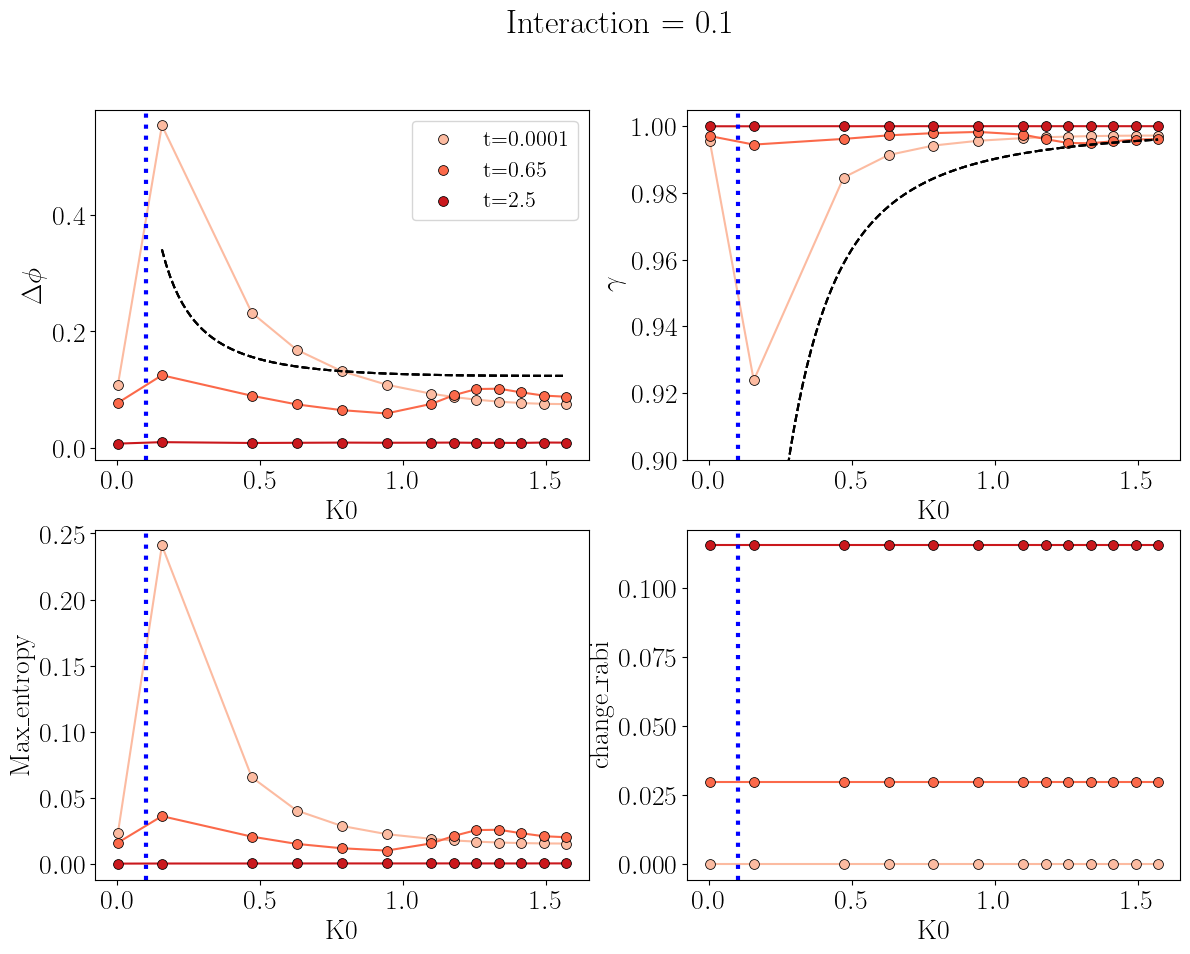

In [ ]:

n_colors = len(tlist)
colors = [plt.cm.Reds(i/(n_colors+1)) for i in range(1, n_colors+1)]
# what we expect from von neuman
R2 = np.exp(-(2*Om_*J/K0_cont)**2)
Purity_theo = 0.5*(1+(np.sin(af)**2)* R2+ np.cos(af)**2)

fig, ax = plt.subplots(2,2,figsize=(2*bwidth,2*bheight))

plt.suptitle("Interaction = {}".format(Om_))

for i in range(0,len(tlist)):
    ti = tlist[i]
    sns.lineplot(ax=ax[0,0], data= data_df[data_df["t"]==ti], x="K0", y="Delta_phi_max", color=colors[i], zorder=0)
    sns.scatterplot(ax=ax[0,0], data= data_df[data_df["t"]==ti], x="K0", y="Delta_phi_max", label="t={}".format(ti), s=50, edgecolor="black",  color=colors[i])
    ax[0,0].plot(K0_cont, phase_gain, linestyle="dashed",c="black")

    sns.lineplot(ax=ax[0,1], data= data_df[data_df["t"]==ti], x="K0", y="purity_last", color=colors[i], zorder=0)
    sns.scatterplot(ax=ax[0,1], data= data_df[data_df["t"]==ti], x="K0", y="purity_last",color=colors[i], edgecolor="black", s=50)
    ax[0,1].plot(K0_cont, Purity_theo, linestyle="dashed",c="black")

    sns.lineplot(ax=ax[1,0], data= data_df[data_df["t"]==ti], x="K0", y="Max_entropy", color=colors[i], zorder=0)
    sns.scatterplot(ax=ax[1,0], data= data_df[data_df["t"]==ti], x="K0", y="Max_entropy",color=colors[i], edgecolor="black", s=50)

    sns.lineplot(ax=ax[1,1], data= data_df[data_df["t"]==ti], x="K0", y="change_rabi", color=colors[i], zorder=0)
    sns.scatterplot(ax=ax[1,1], data= data_df[data_df["t"]==ti], x="K0", y="change_rabi",color=colors[i], edgecolor="black", s=50)

ax[0,0].axvline(Δk, color="blue", linewidth=3, linestyle="dotted")
ax[0,1].axvline(Δk, color="blue", linewidth=3, linestyle="dotted")
ax[1,0].axvline(Δk, color="blue", linewidth=3, linestyle="dotted")
ax[1,1].axvline(Δk, color="blue", linewidth=3, linestyle="dotted")

ax[0,0].set_ylabel(r"$\Delta \phi$")
ax[0,1].set_ylabel(r"$\gamma$")

ax[0,1].set_ylim(0.9, 1.005)

#plt.tight_layout()

plt.savefig(fig_route+"summary_final_obs.png", bbox_inches="tight")

### Zooming into the t=0.00001 vs t=0.5 regime

Here we choose our candidate ($k_0$, $t$) point to represent the coherent dynamics regime beyond von Neuman an such

In [ ]:
data_df.t.unique()
print(K0_unique)
print("choose a k0 above this")
print(np.pi/3)

K0_ = K0_unique[-4]
print("we chose:", K0_)  


[0.00318486 0.15707963 0.4712389  0.62831853 0.78539816 0.9424778
 1.09955743 1.17809725 1.25663706 1.33517688 1.41371669 1.49225651
 1.57079633]
choose a k0 above this
1.0471975511965976
we chose: 1.335176877775662


maximum entropy at:  0.02580669871058741
t value where maximum entropy:  0.65
t value where maximum backaction:  0.65


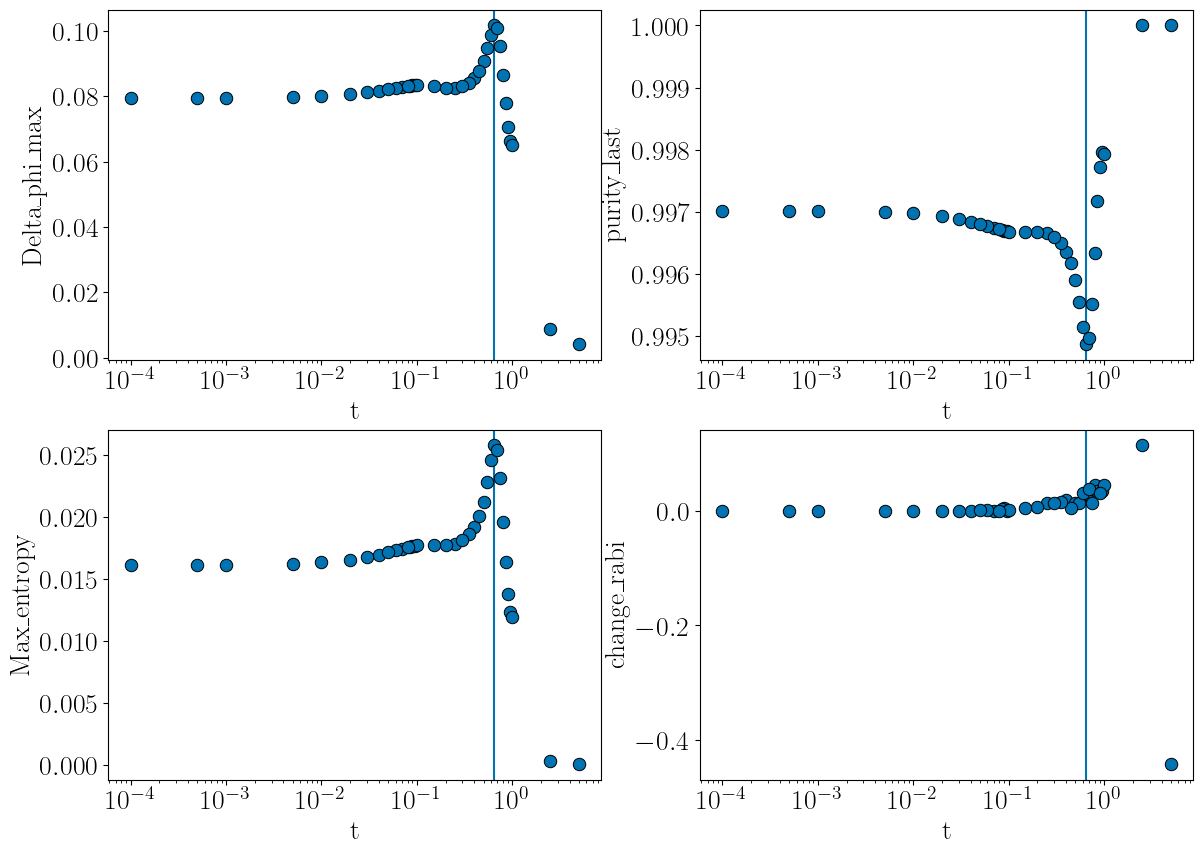

In [ ]:
print("maximum entropy at: ", data_df[data_df["K0"]==K0_]["Max_entropy"].max())
print("t value where maximum entropy: ", data_df[(data_df["K0"]==K0_) & (data_df["Max_entropy"]==data_df[data_df["K0"]==K0_]["Max_entropy"].max())]["t"].iloc[0])  
print("t value where maximum backaction: ", data_df[(data_df["K0"]==K0_) & (data_df["Delta_phi_max"]==data_df[data_df["K0"]==K0_]["Delta_phi_max"].max())]["t"].iloc[0])  


fig, ax = plt.subplots(2,2,figsize=(2*bwidth,2*bheight))
sns.scatterplot(ax=ax[0,0], data=data_df[data_df["K0"]==K0_], x="t", y="Delta_phi_max",  edgecolor="black", s=80)
sns.scatterplot(ax=ax[0,1], data=data_df[data_df["K0"]==K0_], x="t", y="purity_last",  edgecolor="black", s=80)
sns.scatterplot(ax=ax[1,0], data=data_df[data_df["K0"]==K0_], x="t", y="Max_entropy",  edgecolor="black", s=80)
sns.scatterplot(ax=ax[1,1], data=data_df[data_df["K0"]==K0_], x="t", y="change_rabi",  edgecolor="black", s=80)

ax[0,0].axvline(0.65, zorder=0)
ax[0,1].axvline(0.65, zorder=0)
ax[1,0].axvline(0.65, zorder=0)
ax[1,1].axvline(0.65, zorder=0)


ax[0,0].set_xscale("log")
ax[0,1].set_xscale("log")
ax[1,0].set_xscale("log")
ax[1,1].set_xscale("log")

plt.savefig(fig_route+"summary_final_obs_v_Rabi.png", bbox_inches="tight")

## Summarizing the Dynamics

here we use full_df because we want to gauge the effect of Omega

In [ ]:
def plot_grid(obs_string, tlist, K0list, Om_list):
    # this functions takes the columns name that we want to plot and 
    # plots the time evolution for each k0 t of interest, with colors set by Om_list
    
    fig, ax = plt.subplots(3,3,figsize=(2*bwidth,1.8*bwidth), sharex=False, sharey=False)
    n_colors = len(Om_list)
    colors = [plt.cm.Reds(i/(n_colors+1)) for i in range(1, n_colors+1)]        

    for i in range(0,len(tlist)):
        # iterate columns
        ti = tlist[i]
        # iterate rows
        for j in range(0,len(K0list)):
            K0i = K0list[j]       
            # iterate colors
            for l in range(0,len(Om_list)):
                Omi = Om_list[l]
                cond_ = (full_data_df["alfabond"]==af) & (full_data_df["Omega"]==Omi) & (full_data_df["t"]==ti)  & (full_data_df["K0"]==K0i)
                curr_df = full_data_df[cond_].copy()
                # we have to keep track of the time ranges
                if obs_string == "Delta_phi":
                    time_range = curr_df["times"].item()[1:] # we skip the first to match the phase
                    obsdata = curr_df[obs_string].item()

                elif obs_string=="d0_density":
                    # plot first rabi case
                    d0_density = curr_df["d0_density"].item()
                    time_range = np.asarray(curr_df["times"].item())
                    rhot = curr_df["qubit_rho"].item()

                    if ti > 1.0:
                        number_osc = 0.1
                    else:
                        number_osc = 2

                    time_full, n0_full = extend_qubit_occupations(rhot[-1],curr_df["t"].item(), d0_density ,time_range, num_osc=number_osc)
                    time_range = time_full
                    obsdata = n0_full

                else:
                    time_range = curr_df["times"].item()
                    obsdata = curr_df[obs_string].item()

                # plot the legends in one side
                ax[j,i].plot(time_range, obsdata, color=colors[l], label="Om={}".format(Omi), linewidth=2)
                ax[j,i].set_title("K0 = {:.3f}, t = {}".format(K0i, ti), fontsize=base_font-2)
                ax[j,i].tick_params(axis="both", labelsize=base_font-4) 

                # plot the meassurement time
                vg_lat = 2*J*np.sin(K0i)
                tau_lat = (Bindex - X0_)/vg_lat
                # Measurement time window in a lattice
                Spread_lattice = (Δ/np.sqrt(2))*np.sqrt(1 + ( 2*J*np.cos(K0i)*tau_lat/(0.5*Δ**2) )**2 )
                t_measure = Spread_lattice/vg_lat

                ax[j,i].axvline(tau_lat-t_measure, color="blue", linewidth=2, linestyle="dotted")
                ax[j,i].axvline(tau_lat+t_measure, color="blue", linewidth=2, linestyle="dotted")


    ax[1,0].set_ylabel(obs_string)
    ax[2,1].set_xlabel("Time")
    ax[0,2].legend()


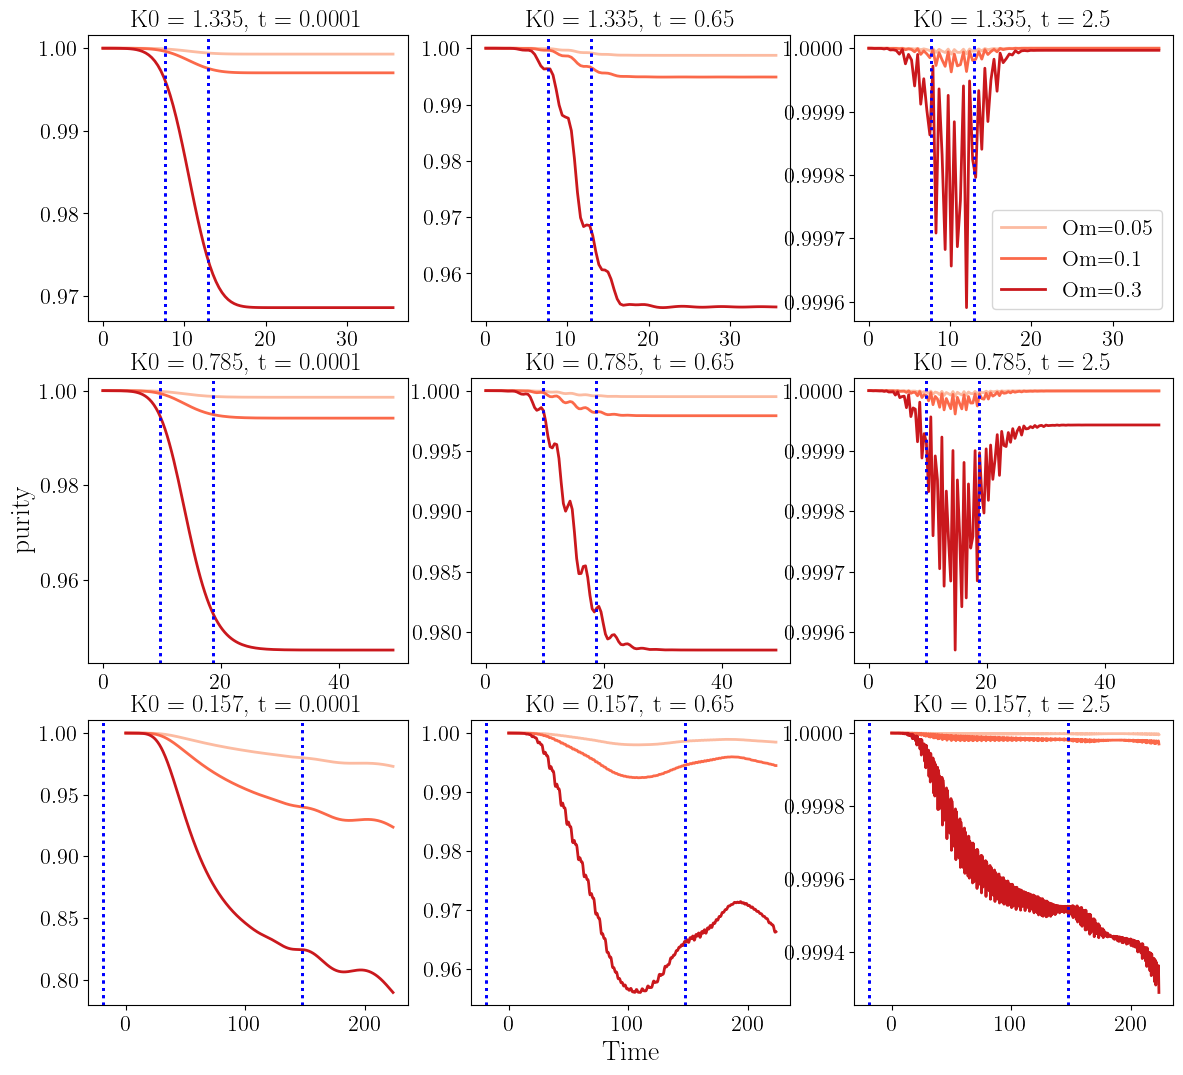

In [ ]:
plot_grid("purity", tlist, K0list, Om_list)

plt.savefig(fig_route+"purity_grid.png", bbox_inches="tight")

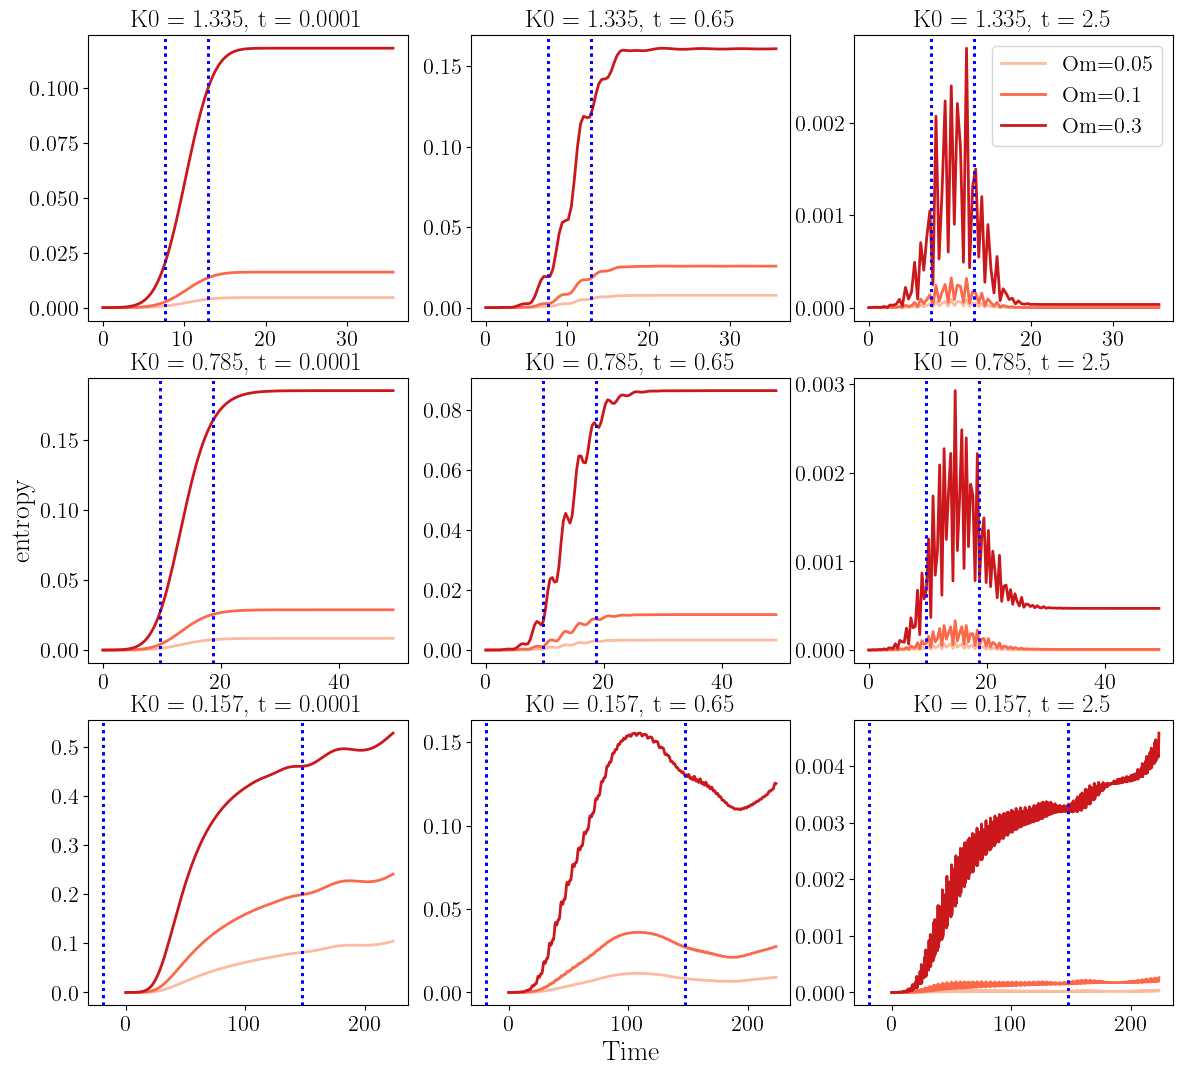

In [ ]:
plot_grid("entropy", tlist, K0list, Om_list)
plt.savefig(fig_route+"entropy_grid.png", bbox_inches="tight")

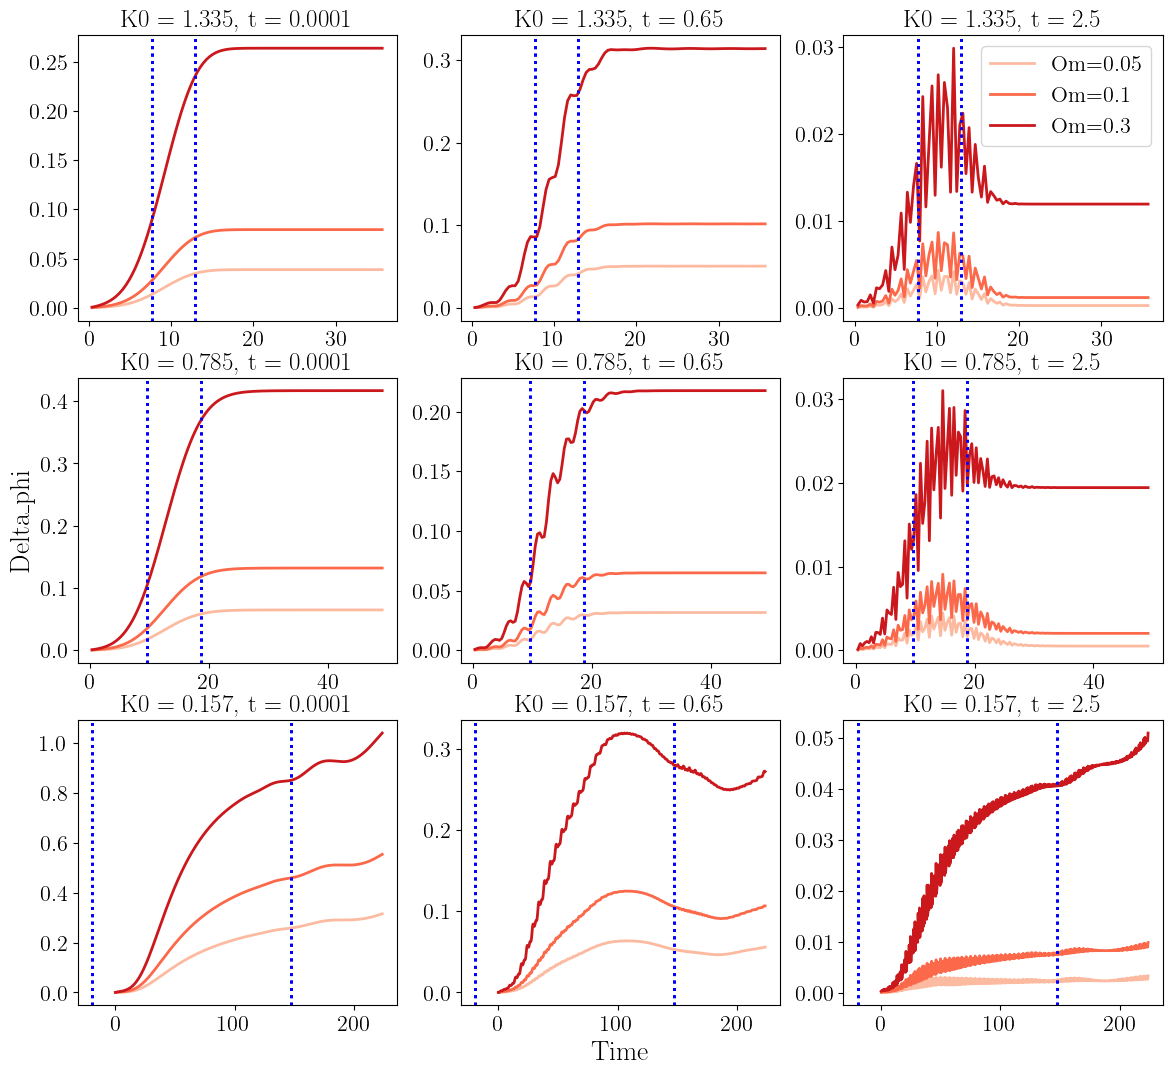

In [ ]:
plot_grid("Delta_phi", tlist, K0list, Om_list)
plt.savefig(fig_route+"phase_grid.png", bbox_inches="tight")

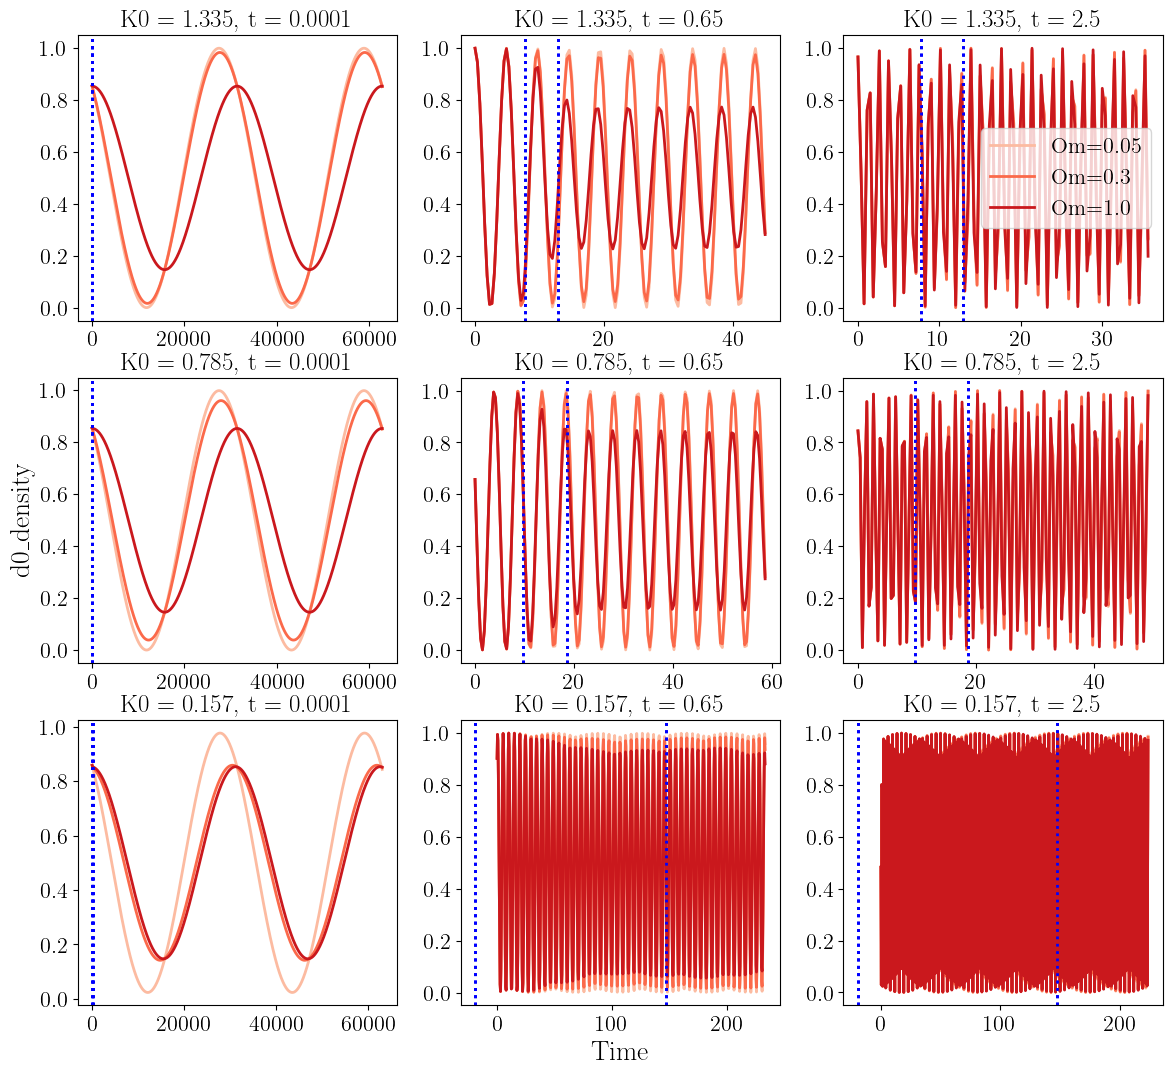

In [ ]:
plot_grid("d0_density", tlist, K0list, [0.05, 0.3 , 1.0])
plt.savefig(fig_route+"t_evol_grid.png", bbox_inches="tight")

In [ ]:
np.sort(full_data_df["t"].unique())

array([0.0e+00, 1.0e-04, 5.0e-04, 1.0e-03, 5.0e-03, 1.0e-02, 2.0e-02,
       3.0e-02, 4.0e-02, 5.0e-02, 6.0e-02, 7.0e-02, 8.0e-02, 8.5e-02,
       9.0e-02, 9.5e-02, 1.0e-01, 1.5e-01, 2.0e-01, 2.5e-01, 3.0e-01,
       3.5e-01, 4.0e-01, 4.5e-01, 5.0e-01, 5.5e-01, 6.0e-01, 6.5e-01,
       7.0e-01, 7.5e-01, 8.0e-01, 8.5e-01, 9.0e-01, 9.5e-01, 1.0e+00,
       2.5e+00, 5.0e+00])

Text(0.5, 1.0, 'K0 = 1.335, t = 2.5, Om=0.1')

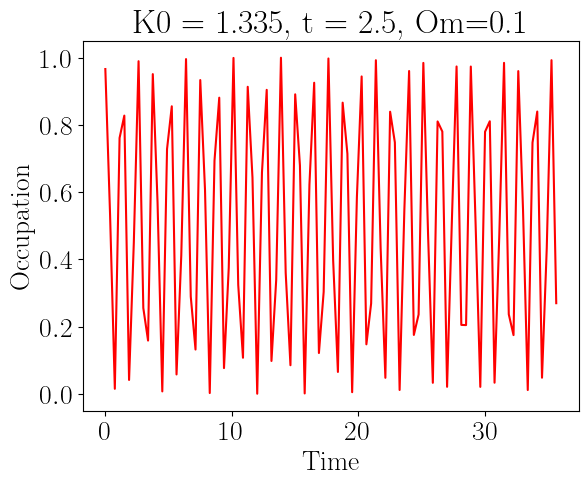

In [ ]:
time_full, n0_full = extend_qubit_occupations(rhot[-1], rabit, d0_density ,time_range, num_osc=osc_number)
Omi = 0.1
ti = 2.5
K0i = K0list[0]
cond_ = (full_data_df["alfabond"]==af) & (full_data_df["Omega"]==Omi) & (full_data_df["t"]==ti)  & (full_data_df["K0"]==K0i)
curr_df = full_data_df[cond_].copy()

# plot first rabi case
d0_density = curr_df["d0_density"].item()
time_range = np.asarray(curr_df["times"].item())
rhot = curr_df["qubit_rho"].item()

_, cutidx = find_nearest(time_range, 20)
est_rabi = estimate_const_freq_fft(d0_density[cutidx:], time_full[cutidx:], remove_mean=True, use_hann=True)
print(est_rabi/2)
print((0.5*est_rabi - ti)/ti)

"""if ti > 1.0:
    number_osc = 0.1

time_full, n0_full = extend_qubit_occupations(rhot[-1],curr_df["t"].item(), d0_density ,time_range, num_osc=number_osc)
time_range = time_full
obsdata = n0_full"""

plt.plot(time_range, d0_density, label="d0_density", c="red", linewidth=1.5)

plt.xlabel("Time")
plt.ylabel("Occupation")
plt.title("K0 = {:.3f}, t = {}, Om={}".format(K0i , ti, Omi))

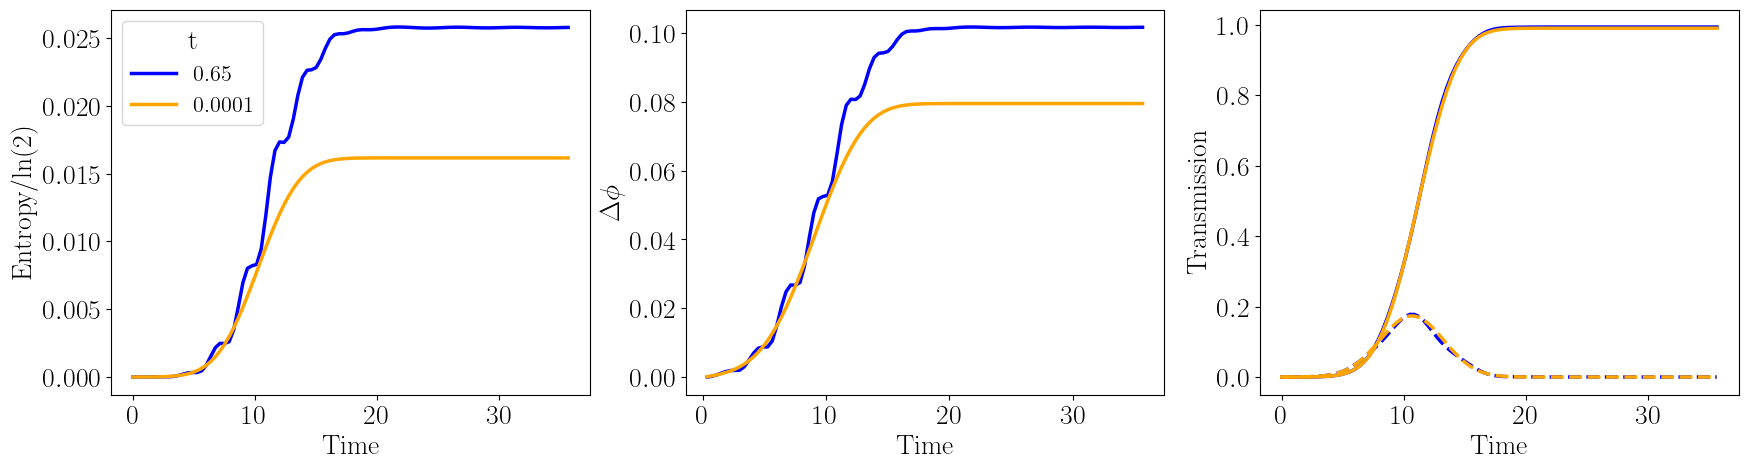

In [30]:
fig, ax = plt.subplots(1,3,figsize=(3*bwidth,bheight))

# first case
cond_ = (data_df["K0"]==K0_unique[-4]) & (data_df["t"]==0.65) 
ax[0].plot(data_df[cond_]["times"].item(), data_df[cond_]["entropy"].item(), label=0.65, linewidth=2.5, c = "blue")
ax[1].plot(data_df[cond_]["times"].item()[1:], data_df[cond_]["Delta_phi"].item(), linewidth=2.5, c ="blue")
# transmission
traj_matrix = data_df[cond_]["occupations"].item()
occu_T = np.sum(traj_matrix[Bindex+2:, :], axis=0)
occu_B = np.sum(traj_matrix[Bindex:Bindex+2, :], axis=0)

ax[2].plot(data_df[cond_]["times"].item(), occu_T, linewidth=2.5,c = "blue")
ax[2].plot(data_df[cond_]["times"].item(), occu_B, linewidth=2.5,c = "blue", linestyle="dashed")

# second case
cond_ = (data_df["K0"]==K0_unique[-4]) & (data_df["t"]==0.0001) 
ax[0].plot(data_df[cond_]["times"].item(), data_df[cond_]["entropy"].item(), label= 0.0001, linewidth=2.5, c = "orange")
ax[1].plot(data_df[cond_]["times"].item()[1:], data_df[cond_]["Delta_phi"].item(), label=0.65,linewidth=2.5, c = "orange")
# transmission
traj_matrix = data_df[cond_]["occupations"].item()
occu_T = np.sum(traj_matrix[Bindex+2:, :], axis=0)
occu_B = np.sum(traj_matrix[Bindex:Bindex+2, :], axis=0)

ax[2].plot(data_df[cond_]["times"].item(), occu_T, linewidth=2.5, c = "orange")
ax[2].plot(data_df[cond_]["times"].item(), occu_B, linewidth=2.5,c = "orange", linestyle="dashed")


ax[0].set_xlabel("Time")
ax[0].set_ylabel("Entropy/ln(2)")
ax[1].set_xlabel("Time")
ax[1].set_ylabel(r"$$\Delta \phi$$")
ax[2].set_xlabel("Time")
ax[2].set_ylabel(r"Transmission")


ax[0].legend(title="t")

plt.savefig(fig_route+"compare_regime.png", bbox_inches="tight")

# Single Example

In [116]:
t_ = 2.5
Om = 0.1

k0_ = K0_unique[-1] 
print(k0_)
cond_ = (full_data_df["t"]==t_)  & (full_data_df["K0"]==k0_) & (full_data_df["alfabond"]==af) & (full_data_df["Omega"]== Om )

curr_df = full_data_df[cond_].copy()
time_range = np.asarray(curr_df["times"].item())    
Δ = curr_df["Spread"].item() # initial spread of the wavepacket
Bindex = curr_df.bond_index.item()# position of the bond
# spread at time of measurement
Spread_B = (Δ/np.sqrt(2))*np.sqrt(1 + ( (Bindex - X0_)/(Δ*Δ*k0_))**2 )
# density matrix in time 
rhot = curr_df["qubit_rho"].item()


1.5707963267948966


### Wave function and Scattering

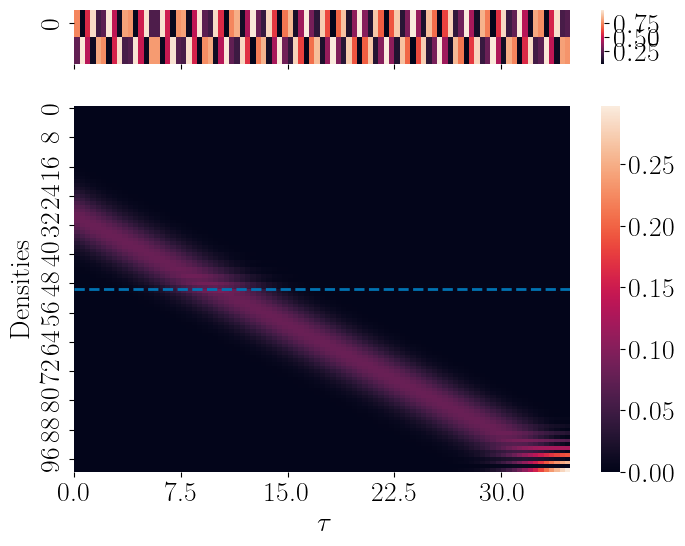

In [117]:
fig, ax = plt.subplots(2,1,figsize=(8,6), sharex=True ,gridspec_kw={'height_ratios': [0.15, 1]})

# n_d1
n_d1 = curr_df["d0_density"].item()
sns.heatmap([n_d1,1-n_d1],ax=ax[0])
traj_matrix = curr_df["occupations"].item()
time_range = curr_df["times"].item()
sns.heatmap(traj_matrix,ax=ax[1])

ax[1].set_xlabel(r"$\tau$")

ax[1].set_ylabel("Densities")

# time ticks
delta_tau = time_range[1] - time_range[0]
tick_posx = np.arange(0,len(time_range),20)
xtick_label = np.around(tick_posx*(delta_tau),decimals=1)

ax[1].axhline(curr_df["bond_index"].item(), linewidth=2, linestyle="dashed")
ax[1].set_xticks(tick_posx,xtick_label);

0.9993624260871841


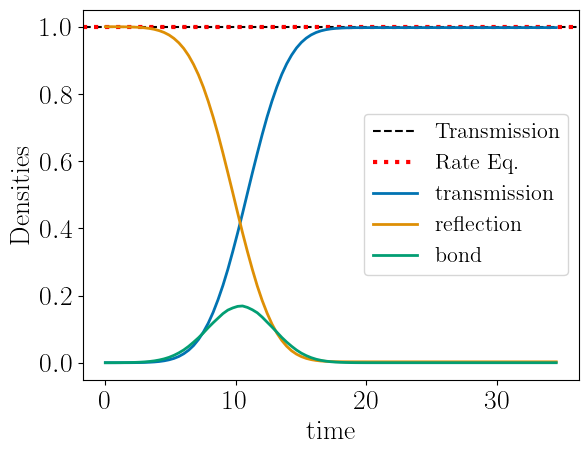

In [118]:
# notice hoow tis not the renormalized interaction strength
# baecause this is the stationary limit and NOT von neuman
V0 = Om*prob0
Tprob = get_transmision_proba(V0, k0_, Δ)

# from gurvitz/romito
Tinit = 1 # unocupeid proba

currexp = Tinit+prob0*(Tprob-Tinit)
print(currexp)

traj_matrix = curr_df["occupations"].item()
# occupation to the right of the bond at
occu_T = np.sum(traj_matrix[Bindex+2:, :], axis=0)
occu_R = np.sum(traj_matrix[:Bindex, :], axis=0)
occu_B = np.sum(traj_matrix[Bindex:Bindex+2, :], axis=0)
# from the numerics this is
plt.axhline(Tprob, color="black", linestyle="dashed", label="Transmission")
plt.axhline(currexp, color="red", linestyle="dotted", linewidth=3, label="Rate Eq.")
plt.plot(time_range,occu_T, label="transmission", linewidth=2)
plt.plot(time_range,occu_R, label="reflection", linewidth=2)
plt.plot(time_range, occu_B, label="bond", linewidth=2 )

plt.xlabel("time")
plt.ylabel("Densities")

plt.legend()

### Freq Change Effect

In [123]:
# first lets extend the range of oscillations of the qubit by applying the independent dynamics as a unitary on the density matrix
rhot = curr_df["qubit_rho"].item()
d0_density = curr_df["d0_density"].item()
rhot1 = rhot[0] # save for later
osc_period = np.pi/t_
osc_number = 6
time_full, n0_full = extend_qubit_occupations(rhot[-1], t_, d0_density ,time_range, num_osc=osc_number)


In [124]:
# getting the decoupled evolution for reference
ϕ0 = 0
time_free = np.arange(0, osc_number*osc_period, time_range[2] - time_range[1])
rho_free_list, _, _ = get_free_orbit(rhot[0], curr_df["cos_theta"].item()[0], ϕ0,
                                                               time_free,t_)
n0_free = get_qubit_occupations(rho_free_list)

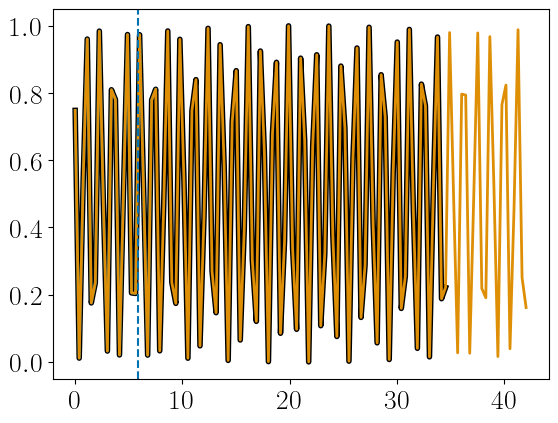

In [125]:
plt.plot(time_range, curr_df["d0_density"].item(), c= "black", linewidth=4)

plt.plot(time_free, n0_free, linewidth=2)
plt.plot(time_full, n0_full,linewidth=2)
plt.axvline(curr_df["time_at_bond"].item(), linestyle="dashed")

original freq =  2.5
new freq =  2.5053108332736396
percent change =  0.0040530120872983135


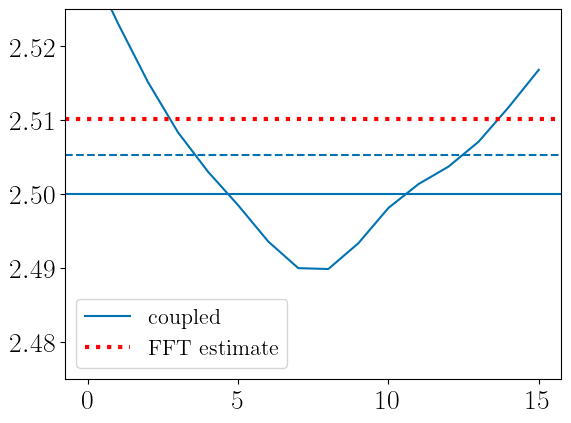

In [127]:
_ , rabi_om = get_instant_freq(n0_free - np.mean(n0_free),time_free)
_ , couple_om = get_instant_freq(n0_full[len(rhot):] - np.mean(n0_full[len(rhot):]),
                                time_full[len(rhot):])

est_rabi= estimate_const_freq_fft(n0_full[len(rhot):], time_full[len(rhot):], remove_mean=True, use_hann=True)
est_t = est_rabi/2

# remove the artifacts from edge effects
rems = int(0.1*len(rabi_om))
rabi_om = rabi_om[rems:-rems]
couple_om = couple_om[rems:-rems]

new_freq = np.mean(couple_om)/2

print("original freq = ", t_)
print("new freq = ", new_freq)
print("percent change = " , (est_t-t_)/t_ )
plt.plot(couple_om/2, label = "coupled")
plt.axhline(new_freq, linestyle="dashed")
plt.axhline(est_t, linestyle="dotted", c="red", linewidth=3 ,label="FFT estimate")
plt.axhline(t_)
plt.legend()
plt.ylim(t_- 0.01*t_, t_+0.01*t_);

In [ ]:
"""time_full, n0_full = extend_qubit_occupations(rhot[-1], rabit, d0_density ,time_range, num_osc=osc_number)
Omi = 0.1
ti = 2.5
K0i = K0list[0]
cond_ = (full_data_df["alfabond"]==af) & (full_data_df["Omega"]==Omi) & (full_data_df["t"]==ti)  & (full_data_df["K0"]==K0i)
curr_df = full_data_df[cond_].copy()

d0_density = curr_df["d0_density"].item()
time_range = np.asarray(curr_df["times"].item())
rhot = curr_df["qubit_rho"].item()

_, cutidx = find_nearest(time_range, 20)
est_rabi = estimate_const_freq_fft(d0_density[cutidx:], time_full[cutidx:], remove_mean=True, use_hann=True)
print(est_rabi/2)
print((0.5*est_rabi - ti)/ti)"""

### Entropy and Purity

Text(0, 0.5, 'Purity')

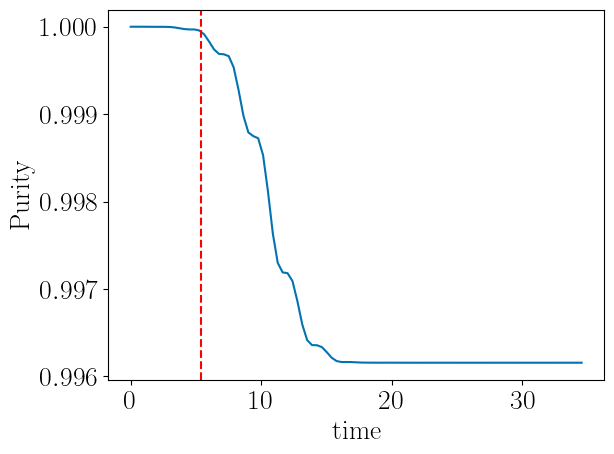

In [27]:
plt.plot(time_range,curr_df["purity"].item())
plt.axvline(curr_df["time_at_bond"].item(), color="red", linestyle="dashed", label="Time at bond")
plt.xlabel("time")
plt.ylabel("Purity")

# Scattering

Since we are doing reflectometry, we should compare to the scattering/current regimes that are mentioned in gurvitz ad Korotkov and most literature

In [28]:
# gettinf the transmision proba from literature

print(full_data_df.columns)
# calculate the transmission probas for each Om_
omega_list = np.sort(full_data_df[full_data_df["Omega"]<2].Omega.unique() )
print(omega_list)
colorb_list = sns.color_palette("Blues", len(omega_list))

Index(['L_qpc', 'Omega', 't', 'J', 'Jp', 'bond_index', 'K0', 'X0', 'Spread',
       'maxt_time', 'del_tau', 'qubit_init', 'Re_qubit_0', 'Im_qubit_0',
       'Re_qubit_1', 'Im_qubit_1', 'phi', 'alfabond', 'times', 'occupations',
       'd0_density', 'qubit_rho', 'entropy', 'time_at_bond', 'Max_entropy',
       'cos_theta', 'sin_phi', 'bloch_radius', 'backaction_time',
       'backaction_max', 'Delta_phi', 'Delta_phi_max', 'bloch_radius_last',
       'purity', 'purity_last', 'transmission', 'max_transmission',
       'rabi_final'],
      dtype='object')
[0.05 0.1  0.3  0.6  1.  ]


According to Romit et al. this we require K0_unique/Spread_B To be much bigger than 0.5*(Om_*prob0)**2 for us to have weak measurements. In addition according to korotkov these models should only work when the corrent/ transmission rate on the detector change very little. **THis is essentially the how long/strong is too much which is related to the purity of the qubit, we want to aboid learning too much to keep withhin weak measurements**

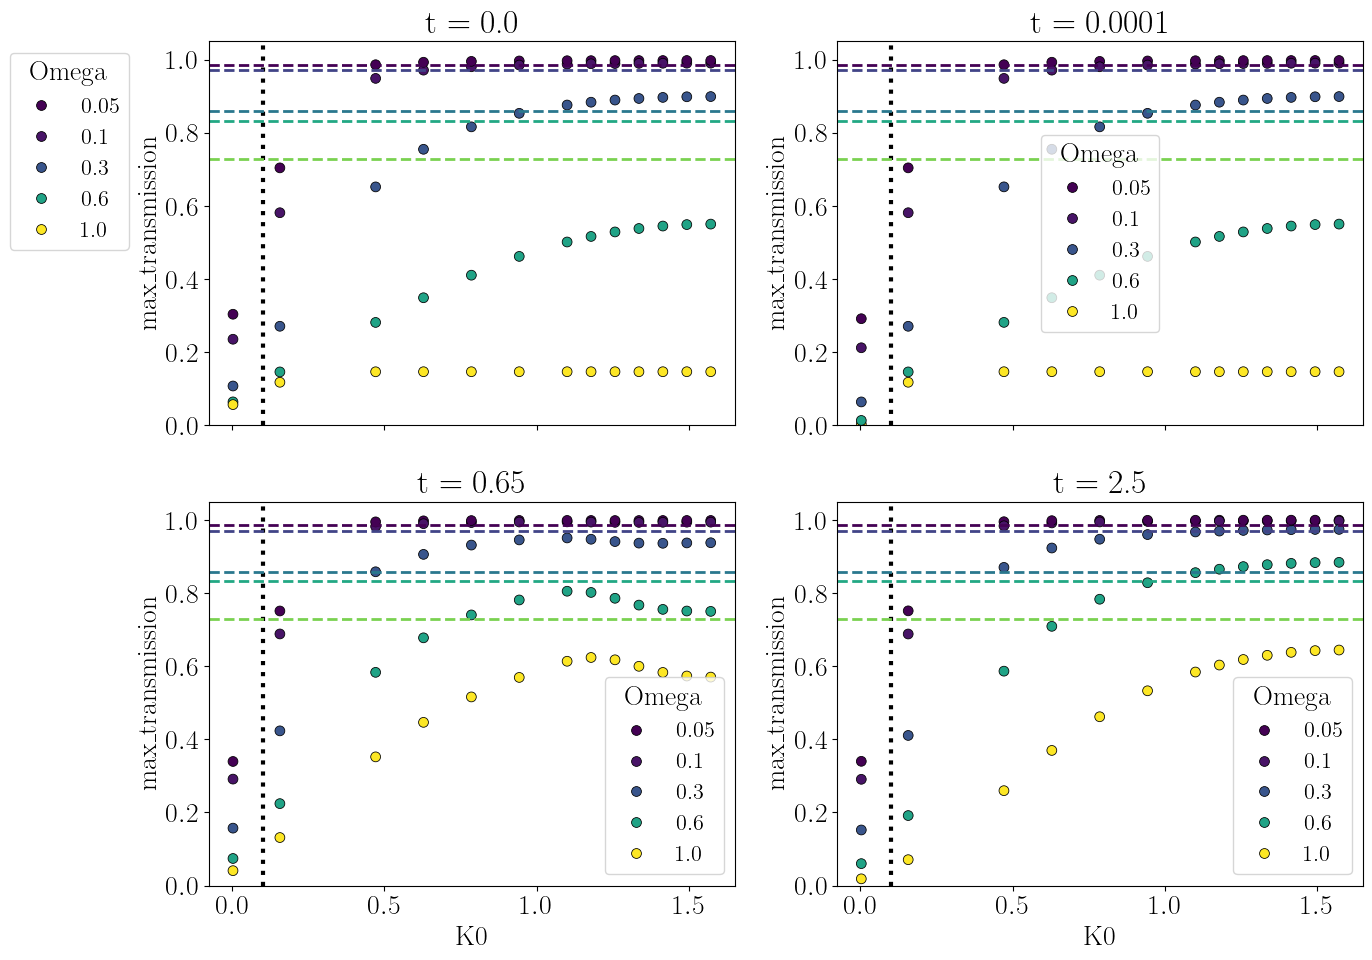

In [29]:
f,ax = plt.subplots(2,2, figsize=(2*bwidth, 2*bheight),sharex=True)


# add the minimum momentum condition
ax[0,0].axvline(Δk, color="black", zorder=0, linewidth=3, linestyle="dotted")
ax[0,1].axvline(Δk, color="black", zorder=0, linewidth=3, linestyle="dotted")
ax[1,0].axvline(Δk, color="black", zorder=0, linewidth=3, linestyle="dotted")
ax[1,1].axvline(Δk, color="black", zorder=0, linewidth=3, linestyle="dotted")

Om_interest = [0.05, 0.1, 0.5, 0.6, 1.0]
t_ = 0.0
# plot condition where theory validity is expected and get colors
cond_ = (full_data_df["alfabond"]==af) & (full_data_df["t"]==t_) & (full_data_df["Omega"]<2)
n_colors = len(full_data_df[cond_]["Omega"].unique())
colors = [plt.cm.viridis(i / n_colors) for i in range(n_colors)]

sns.scatterplot(ax=ax[0,0], x="K0", y="max_transmission", hue="Omega",data=full_data_df[cond_], s=50, edgecolor="black", palette="viridis")

ax[0,0].legend(bbox_to_anchor=(-0.4, 1), loc='upper left', title="Omega")
ax[0,0].set_title("t = {}".format(t_))

t_ = 0.0001
cond_ = (full_data_df["alfabond"]==af) & (full_data_df["t"]==t_) & (full_data_df["Omega"]<2)
sns.scatterplot(ax=ax[0,1], x="K0", y="max_transmission", hue="Omega", data=full_data_df[cond_], s=50, edgecolor="black", palette="viridis")
ax[0,1].set_title("t = {}".format(t_))

t_ = 0.65
cond_ = (full_data_df["alfabond"]==af) & (full_data_df["t"]==t_) & (full_data_df["Omega"]<2)
sns.scatterplot(ax=ax[1,0], x="K0", y="max_transmission", hue="Omega", data=full_data_df[cond_],  s=50, edgecolor="black", palette="viridis")
ax[1,0].set_title("t = {}".format(t_))

t_ = 2.5
cond_ = (full_data_df["alfabond"]==af) & (full_data_df["t"]==t_) & (full_data_df["Omega"]<2)
sns.scatterplot(ax=ax[1,1], x="K0", y="max_transmission", hue="Omega", data=full_data_df[cond_],  s=50, edgecolor="black", palette="viridis")
ax[1,1].set_title("t = {}".format(t_))

ax[0,0].set_ylim(0,1.05)
ax[0,1].set_ylim(0,1.05)
ax[1,0].set_ylim(0,1.05)
ax[1,1].set_ylim(0,1.05)

# PLot the theory results
for i in range(0,len(Om_interest)):
    ax[0,0].axhline((J- (1-prob0)*Om_interest[i])**2, color='black', linestyle='--', linewidth=2, c=colors[i])
    ax[0,1].axhline((J- (1-prob0)*Om_interest[i])**2, color='black', linestyle='--', linewidth=2, c=colors[i])
    ax[1,0].axhline((J- (1-prob0)*Om_interest[i])**2, color='black', linestyle='--', linewidth=2, c=colors[i])
    ax[1,1].axhline((J- (1-prob0)*Om_interest[i])**2, color='black', linestyle='--', linewidth=2, c=colors[i])



plt.tight_layout()


plt.savefig(fig_route+"transmission_vs_K0.png", bbox_inches="tight")

In [30]:
Om = 0.05
cond_ = (full_data_df["alfabond"]==af) & (full_data_df["Omega"]== Om )
om01_df = full_data_df[cond_].pivot(index='K0', columns='t', values='max_transmission')
om01_df.index = [f"{y:.3g}" for y in om01_df.index]

Om = 0.1
cond_ = (full_data_df["alfabond"]==af) & (full_data_df["Omega"]== Om )
om03_df = full_data_df[cond_].pivot(index='K0', columns='t', values='max_transmission')
om03_df.index = [f"{y:.3g}" for y in om03_df.index]

Om = 0.3
cond_ = (full_data_df["alfabond"]==af) & (full_data_df["Omega"]== Om )
om06_df = full_data_df[cond_].pivot(index='K0', columns='t', values='max_transmission')
om06_df.index = [f"{y:.3g}" for y in om06_df.index]

Om = 0.6
cond_ = (full_data_df["alfabond"]==af) & (full_data_df["Omega"]== Om )
om1_df = full_data_df[cond_].pivot(index='K0', columns='t', values='max_transmission')
om1_df.index = [f"{y:.3g}" for y in om1_df.index]


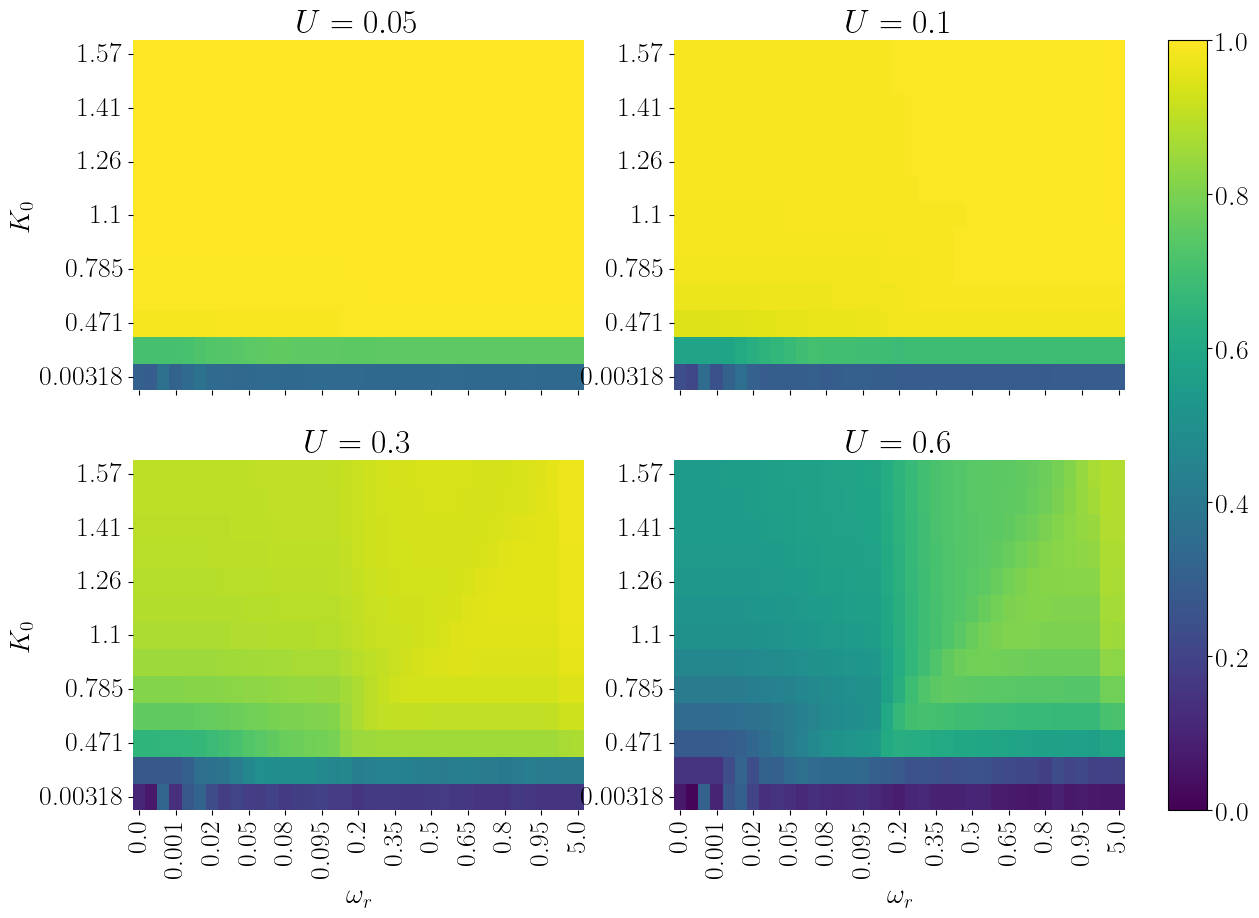

In [31]:
f,ax = plt.subplots(2,2, figsize=(2*bwidth, 2*bheight), sharex=True)
hm = sns.heatmap(om01_df, annot=False, fmt=".2f", cmap="viridis", ax=ax[0,0], vmin=0, vmax=1, cbar=False)
sns.heatmap(om03_df, annot=False, fmt=".2f", cmap="viridis", ax=ax[0,1], vmin=0, vmax=1, cbar=False)
sns.heatmap(om06_df, annot=False, fmt=".2f", cmap="viridis", ax=ax[1,0], vmin=0, vmax=1, cbar=False)
sns.heatmap(om1_df, annot=False, fmt=".2f", cmap="viridis", ax=ax[1,1], vmin=0, vmax=1, cbar=False)


ax[0,0].invert_yaxis()
ax[0,1].invert_yaxis()
ax[1,0].invert_yaxis()
ax[1,1].invert_yaxis()

ax[0,0].set_title(r"$U = 0.05$")
ax[0,1].set_title(r"$U = 0.1$")
ax[1,0].set_title(r"$U = 0.3$")
ax[1,1].set_title(r"$U = 0.6$")
ax[0,0].set_ylabel("$K_0$")
ax[1,0].set_ylabel("$K_0$")
ax[0,0].set_xlabel("")
ax[0,1].set_xlabel("")
ax[1,0].set_xlabel(r"$\omega_r$")
ax[1,1].set_xlabel(r"$\omega_r$")

f.colorbar(hm.collections[0], ax=ax.ravel().tolist(), fraction=0.046, pad=0.04)

#plt.tight_layout()

# Backaction on the qubit

using our analytical boundaries

In [32]:
# filter out for the parameters we want 
back_df = data_df.sort_values(by="K0")
# Delta_phi_max backaction_max
B_df = back_df.pivot(index='K0', columns='t', values='Delta_phi_max')

# Create a pivot table for purity l
purity_pivot = back_df.pivot(index='K0', columns='t', values='purity_last')

boundary_points = back_df[back_df["purity_last"]<0.99][["K0","t","purity_last","Delta_phi_max","backaction_max"]]


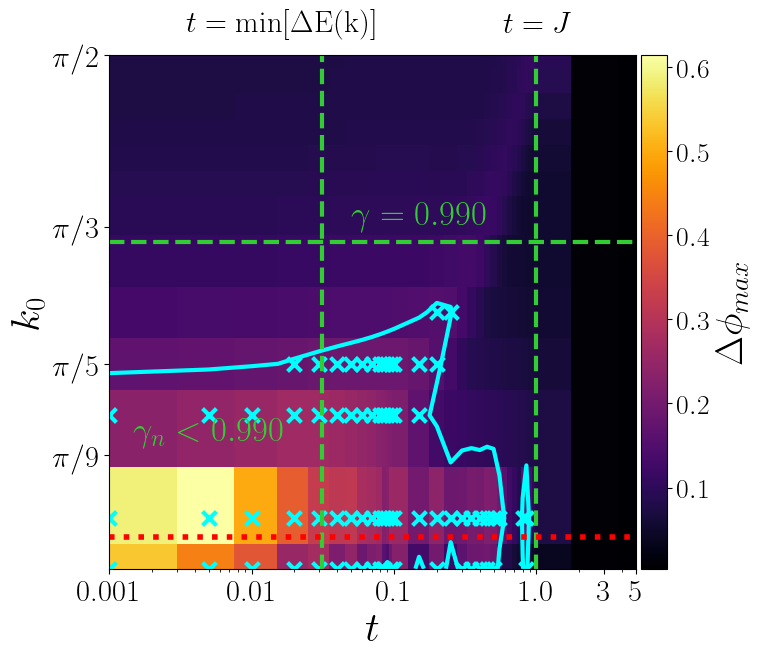

In [33]:
fig, ax = plt.subplots(1,1,figsize=(bwidth+1,bwidth))

vg_array = B_df.index
t_array = B_df.columns
#im = ax.contourf(t_array, vg_array, B_df.values,levels=8, cmap="inferno")
im = ax.pcolormesh(t_array, vg_array, B_df.values, cmap="inferno", shading='auto')

plt.contour(purity_pivot.columns, purity_pivot.index, purity_pivot.values, 
           levels=[0.99], colors='cyan', linewidths=3)

plt.scatter(boundary_points["t"], boundary_points["K0"], 
           color='cyan', s=100, marker='x', linewidth=3)
# lines from perturbation theory
ax.vlines([np.pi/(LL+1), J], ymin=0.0*np.pi/2, ymax=np.pi/2, color='limegreen', lw=3, linestyle="dashed", clip_on=False)  # tick-like line

# Purity according to von Neuman
n_ = 5 # this is the scaling
K0_ = 2*n_*Om_
R2 = np.exp(-(2*Om_/K0_)**2)
purity = 0.5*( 1+ R2*np.sin(af)**2 +np.cos(af)**2 )

ax.axhline(K0_, color='limegreen', lw=3, linestyle="dashed", clip_on=False)  # horizontal line at 2*Omega
ax.axhline(Δk, color="red", linewidth=4, linestyle="dotted")

# get axis scale and ticks
plt.xscale('log')
ax.set_xlim(0.001, 5)
ax.set_ylim(min(K0_unique), max(K0_unique))
ax.set_xticks( [0.001, 0.01,0.1,1.0,3, 5], [0.001, 0.01,0.1,1.0,3,5] ,fontsize=22)
ax.set_yticks( [np.pi/9,np.pi/5,np.pi/3,np.pi/2], labels=[r"$\pi/9$",r"$\pi/5$",r"$\pi/3$",r"$\pi/2$"],fontsize=22 )

# anotate a bit 
ax.annotate(r"$\gamma = {0:.3f}$".format(purity), xy=(0.15, K0_), 
            xytext=(0.15, K0_+0.05),ha='center', c="limegreen", fontsize= 25,fontweight='bold')

ax.annotate(r"$\gamma_n < {0:.3f}$".format(purity), xy=(0.001, np.pi/7 ), 
            xytext=(0.005, np.pi/8),ha='center', c="limegreen", fontsize= 25,fontweight='bold')

y_tick = np.pi/2
ax.annotate(
    r'$t=\rm{min}[ \Delta E(k)]$', 
    xy=(np.pi/(LL+1), y_tick), 
    xytext=(np.pi/(LL+1) - 0.015, y_tick + 0.07), fontsize=22,ha='center')
ax.annotate(
    r'$t=J$', 
    xy=(J, y_tick), 
    xytext=(J, y_tick + 0.07), fontsize=22,ha='center')
# set up color bar
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
cbar = fig.colorbar(im, cax, shrink=0.9)   
cbar.ax.set_ylabel(r'$\Delta \phi_{max}$', rotation=90, fontsize=28)

ax.set_ylabel(r"$k_0$",fontweight='bold',fontsize=30)
ax.set_xlabel(r"$t$",fontweight='bold',fontsize=30)

plt.tight_layout()

## Freq. Change

Gurvitz does mention zeno effect.

Here we can show how much does the qpc affect the qubit by estimating the change in theta. Regarding the zeno effect, the qubit's dynamics become quite important here

[0.05 0.1  0.3  0.6  1.  ]


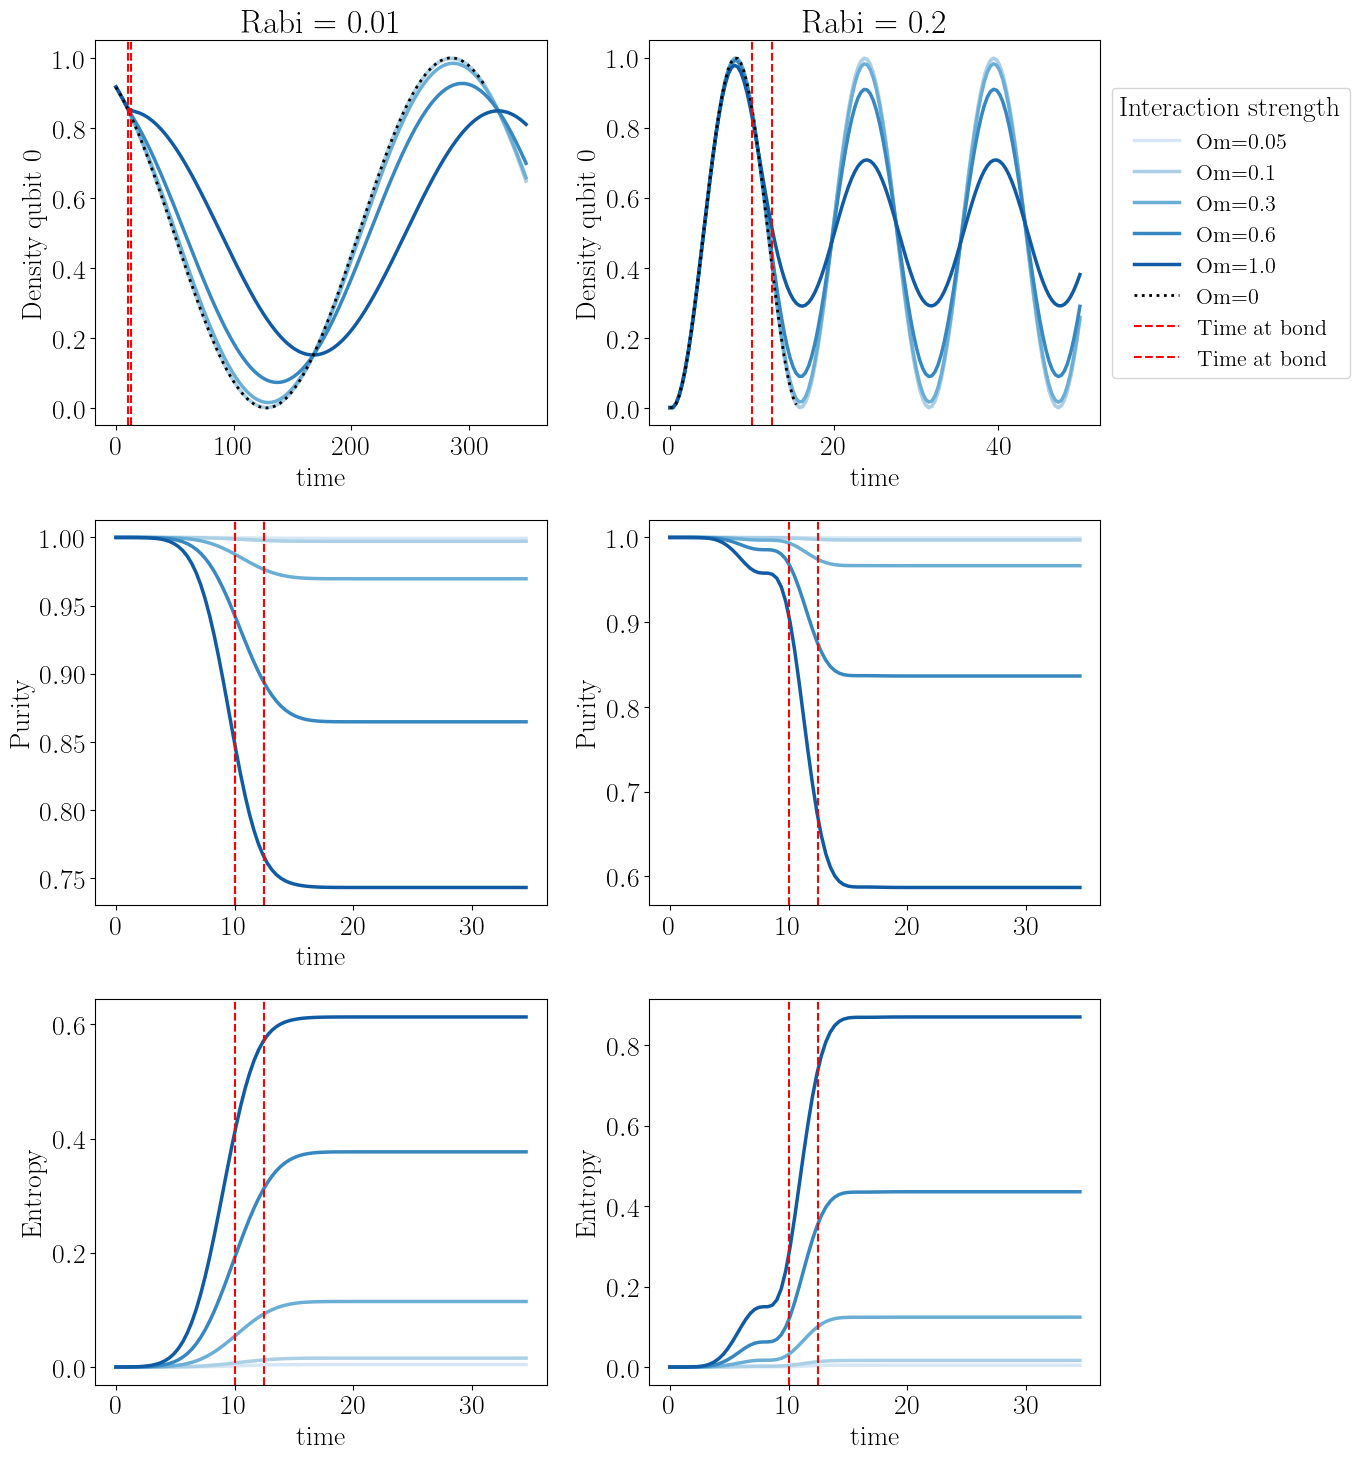

In [34]:

K0 = K0_unique[-1]
vg_lat = 2*J*np.sin(K0)
tau_lat = (Bindex - X0_)/vg_lat
# Measurement time window in a lattice
Spread_lattice = (Δ/np.sqrt(2))*np.sqrt(1 + ( 2*J*np.cos(K0)*tau_lat/(Δ**2) )**2 )
t_measure = Spread_lattice/vg_lat

osc_number = 1
omega_list = np.sort(full_data_df[full_data_df["Omega"]<2]["Omega"].unique())
print(omega_list)
colorb_list = sns.color_palette("Blues", len(omega_list))

fig, ax = plt.subplots(3,2,figsize=(2*bwidth,3*bheight))
for i in range(0, len(omega_list)):
    Om = omega_list[i]
    # plot first rabi case
    rabi1 = 0.01
    osc_period = np.pi/rabi1
    cond_ = (full_data_df["alfabond"]==af) & (full_data_df["Omega"]== Om ) & (full_data_df["K0"]==K0 ) & (full_data_df["t"]==rabi1)
    curr_df = full_data_df[cond_].copy()

    d0_density = curr_df["d0_density"].item()
    time_range = np.asarray(curr_df["times"].item())
    time_range1 = time_range # save now for use later
    rhot = curr_df["qubit_rho"].item()
    rhot1 = rhot[0] # save for later
    # rhot[-1], rabit, d0_density ,time_range, num_osc=osc_numbe
    time_full, n0_full = extend_qubit_occupations(rhot[-1],rabi1, d0_density ,time_range, num_osc=osc_number)

    ax[0,0].plot(time_full, n0_full, lw=2.5, label="Om={}".format(Om), color=colorb_list[i])
    ax[1,0].plot(time_range, curr_df["purity"].item(), lw=2.5,color=colorb_list[i])
    ax[2,0].plot(time_range, curr_df["entropy"].item(), lw=2.5,color=colorb_list[i])

    # plot second rabi case
    rabi2 = 0.2
    osc_period = np.pi/rabi2
    cond_ = (full_data_df["alfabond"]==af) & (full_data_df["Omega"]== Om ) & (full_data_df["K0"]==K0 ) & (full_data_df["t"]==rabi2)
    curr_df = full_data_df[cond_].copy()
    time_range = np.asarray(curr_df["times"].item())
    time_range2 = time_range # save now for use later
    rhot = curr_df["qubit_rho"].item()
    rhot2 = rhot[0]
    d0_density2 = curr_df["d0_density"].item()
  
    time_full, n0_full = extend_qubit_occupations(rhot[-1], rabi2, d0_density2, time_range, num_osc=osc_number)

    ax[0,1].plot(time_full, n0_full, lw=2.5, label="Om={}".format(Om), color=colorb_list[i])
    ax[1,1].plot(time_range, curr_df["purity"].item(), lw=2.5,color=colorb_list[i])
    ax[2,1].plot(time_range, curr_df["entropy"].item(), lw=2.5,color=colorb_list[i])


# getting the decoupled evolution for reference
# first case
ϕ0 = 0
time_free = np.arange(0, osc_number*np.pi/rabi1, time_range[2] - time_range[1])
rho_free_list, _, _ = get_free_orbit(rhot1, curr_df["cos_theta"].item()[0], ϕ0, time_free,rabi1)
n0_free = get_qubit_occupations(rho_free_list)
ax[0,0].plot(time_free, n0_free, lw=2, label="Free evolution", color="black", linestyle="dotted")

# second case
time_free = np.arange(0, osc_number*np.pi/rabi2, time_range[2] - time_range[1])
rho_free_list, _, _ = get_free_orbit(rhot2, curr_df["cos_theta"].item()[0], ϕ0, time_free,rabi2)
n0_free = get_qubit_occupations(rho_free_list)
ax[0,1].plot(time_free, n0_free, lw=2, label="Om=0", color="black", linestyle="dotted")

# plot when the measurement happens in all axis
ax[0,0].axvline(tau_lat, c="red", linestyle='--')
ax[0,0].axvline(tau_lat+t_measure, c="red", linestyle='--')
ax[1,0].axvline(tau_lat, c="red", linestyle='--')
ax[1,0].axvline(tau_lat+t_measure, c="red", linestyle='--')
ax[2,0].axvline(tau_lat, c="red", linestyle='--')
ax[2,0].axvline(tau_lat+t_measure, c="red", linestyle='--')
ax[1,0].axvline(tau_lat, c="red", linestyle='--')
ax[1,0].axvline(tau_lat+t_measure, c="red", linestyle='--')
ax[0,1].axvline(tau_lat, c="red", linestyle='--', label="Time at bond")
ax[0,1].axvline(tau_lat+t_measure, c="red", linestyle='--', label="Time at bond")

ax[1,1].axvline(tau_lat, c="red", linestyle='--')
ax[1,1].axvline(tau_lat+t_measure, c="red", linestyle='--')
ax[2,1].axvline(tau_lat, c="red", linestyle='--')
ax[2,1].axvline(tau_lat+t_measure, c="red", linestyle='--')

ax[0,0].set_xlabel("time")
ax[0,0].set_ylabel("Density qubit 0")
# ax[0,0].set_ylim(0.8,0.9)
ax[0,0].set_title("Rabi = {}".format(rabi1))
ax[1,0].set_xlabel("time")
ax[1,0].set_ylabel("Purity")
ax[2,0].set_xlabel("time")
ax[2,0].set_ylabel("Entropy")

ax[0,1].legend(title="Interaction strength",loc='center left', bbox_to_anchor=(1, 0.5))
ax[0,1].set_xlabel("time")
ax[0,1].set_ylabel("Density qubit 0")
# ax[0,1].set_ylim(-0.03,1.03)
ax[1,1].set_ylabel("Purity")
ax[0,1].set_title("Rabi = {}".format(rabi2))

ax[2,1].set_xlabel("time")
ax[2,1].set_ylabel("Entropy")


plt.tight_layout()

plt.savefig(fig_route+"density_and_purity_time_evolution.png", bbox_inches="tight")

# Entanglement and Info gain

How much more do we gain by looking at the information gain near the t=0.1 regime? because here we reduce the backaction.

In [35]:
# filter out for the parameters we want 
cond_ = (data_df["Omega"]==Om_)  & (data_df["qubit_init"]=="fixed") & (data_df["X0"]==X0_) & (data_df["alfabond"]==af)

data_S = data_df[cond_].sort_values(by="K0")
# FOR NOW
# data_S = data_S.drop_duplicates(subset=["K0", "t"], keep="first")
S_df = data_S.pivot(index='K0', columns='t', values='Max_entropy')


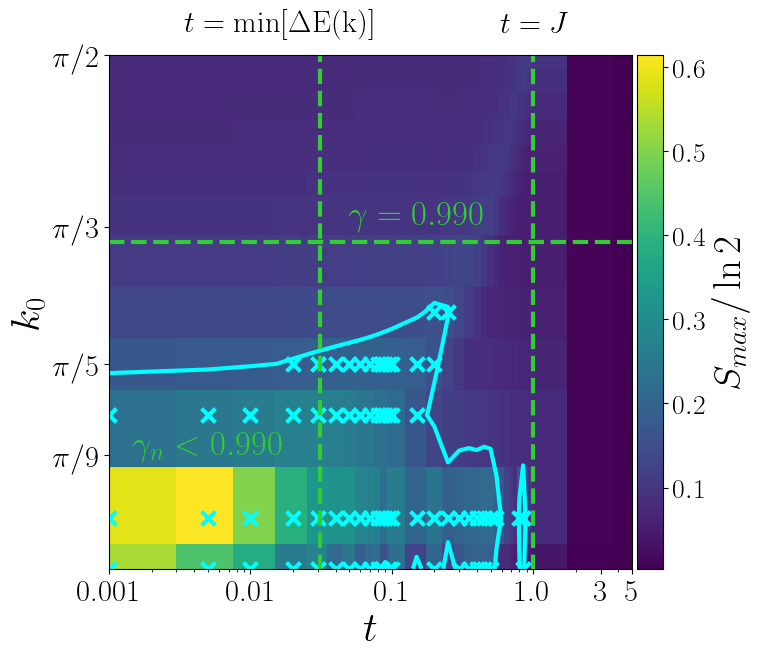

In [36]:
fig, ax = plt.subplots(1,1,figsize=(bwidth+1,bwidth))

vg_array = S_df.index
t_array = S_df.columns
#im = ax.contourf(t_array, vg_array, S_df.values,levels=8, cmap="viridis")
im = ax.pcolormesh(t_array, vg_array, B_df.values, cmap="viridis", shading='auto')

plt.contour(purity_pivot.columns, purity_pivot.index, purity_pivot.values, 
           levels=[0.99], colors='cyan', linewidths=3)

plt.scatter(boundary_points["t"], boundary_points["K0"], 
           color='cyan', s=100, marker='x', linewidth=3)
# lines from perturbation theory
ax.vlines([np.pi/(LL+1), J], ymin=0.0*np.pi/2, ymax=np.pi/2, color='limegreen', lw=3, linestyle="dashed", clip_on=False)  

# Purity according to von Neuman
n_ = 5 # this is the scaling
K0_ = 2*n_*Om_
R2 = np.exp(-(2*Om_/K0_)**2)
purity = 0.5*( 1+ R2*np.sin(af)**2 +np.cos(af)**2 )

ax.axhline(K0_, color='limegreen', lw=3, linestyle="dashed", clip_on=False)  # horizontal line at 2*Omega

# get axis scale and ticks
plt.xscale('log')
ax.set_xlim(0.001, 5)
ax.set_ylim(min(K0_unique), max(K0_unique))
ax.set_xticks( [0.001, 0.01,0.1,1.0,3, 5], [0.001, 0.01,0.1,1.0,3,5] ,fontsize=22)
ax.set_yticks( [np.pi/9,np.pi/5,np.pi/3,np.pi/2], labels=[r"$\pi/9$",r"$\pi/5$",r"$\pi/3$",r"$\pi/2$"],fontsize=22 )

# anotate a bit 
ax.annotate(r"$\gamma = {0:.3f}$".format(purity), xy=(0.15, K0_), 
            xytext=(0.15, K0_+0.05),ha='center', c="limegreen", fontsize= 25,fontweight='bold')

ax.annotate(r"$\gamma_n < {0:.3f}$".format(purity), xy=(0.001, np.pi/9), 
            xytext=(0.005, np.pi/9),ha='center', c="limegreen", fontsize= 25,fontweight='bold')

y_tick = np.pi/2
ax.annotate(
    r'$t=\rm{min}[ \Delta E(k)]$', 
    xy=(np.pi/(LL+1), y_tick), 
    xytext=(np.pi/(LL+1) - 0.015, y_tick + 0.07), fontsize=22,ha='center')
ax.annotate(
    r'$t=J$', 
    xy=(J, y_tick), 
    xytext=(J, y_tick + 0.07), fontsize=22,ha='center')
# set up color bar
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
cbar = fig.colorbar(im, cax, shrink=0.9)   
cbar.ax.set_ylabel(r'$S_{max}/\ln{2}$', rotation=90, fontsize=28)

ax.set_ylabel(r"$k_0$",fontweight='bold',fontsize=30)
ax.set_xlabel(r"$t$",fontweight='bold',fontsize=30)

plt.tight_layout()

plt.savefig(fig_route+"entropy_vs_K0_and_t.png", bbox_inches="tight")

# What about a changing the qubit occupation at measurement?

Remeber that the interaction is actually hooked up to the $\ket{1}$ state

In [37]:
print(full_data_df["alfabond"].sort_values().unique())
alfa = full_data_df["alfabond"].unique()[2]
print(np.cos(alfa/2)**2)

[0.         0.31415927 0.78539816 1.57079633]
0.5000000000000001


In [38]:
print(np.cos(full_data_df["alfabond"].unique()[0]/2)**2)
print(np.cos(full_data_df["alfabond"].unique()[1]/2)**2)
print(np.cos(full_data_df["alfabond"].unique()[2]/2)**2)
print(np.cos(full_data_df["alfabond"].unique()[3]/2)**2)

0.9755282581475768
0.8535533905932737
0.5000000000000001
1.0


In [39]:
K0 = K0_unique[-1]
print(K0,rabi)
omega_list = np.sort(full_data_df[full_data_df["Omega"]<11]["Omega"].unique())
print(omega_list)
colorb_list = sns.color_palette("Blues", len(omega_list))

fig, ax = plt.subplots(2,3,figsize=(2.5*bwidth,2*bheight))
for i in range(0, len(omega_list)):
    Om = omega_list[i]
    # plot first rabi case
    rabi1 = 0.001
    cond_ = (full_data_df["alfabond"]==alfa) & (full_data_df["Omega"]== Om ) & (full_data_df["K0"]==K0 ) & (full_data_df["t"]==rabi1)
    curr_df = full_data_df[cond_].copy()
    time_range = np.asarray(curr_df["times"].item())
    ax[0,0].plot(time_range, curr_df["d0_density"].item(), lw=2.5, label="Om={}".format(Om), color=colorb_list[i])
    ax[1,0].plot(time_range, curr_df["purity"].item(), lw=2.5,color=colorb_list[i])

    # plot second rabi case
    rabi2 = 0.1
    cond_ = (full_data_df["alfabond"]==alfa) & (full_data_df["Omega"]== Om ) & (full_data_df["K0"]==K0 ) & (full_data_df["t"]==rabi2)
    curr_df = full_data_df[cond_].copy()
    time_range = np.asarray(curr_df["times"].item())
    ax[0,1].plot(time_range, curr_df["d0_density"].item(), lw=2.5, label="Om={}".format(Om), color=colorb_list[i])
    ax[1,1].plot(time_range, curr_df["purity"].item(), lw=2.5,color=colorb_list[i])

    # plot third rabi case
    rabi3 = 1.0
    cond_ = (full_data_df["alfabond"]==alfa) & (full_data_df["Omega"]== Om ) & (full_data_df["K0"]==K0 ) & (full_data_df["t"]==rabi3)
    curr_df = full_data_df[cond_].copy()
    time_range = np.asarray(curr_df["times"].item())
    ax[0,2].plot(time_range, curr_df["d0_density"].item(), lw=2.5, label="Om={}".format(Om), color=colorb_list[i])
    ax[1,2].plot(time_range, curr_df["purity"].item(), lw=2.5,color=colorb_list[i])

time_at_bond = (Bindex - X0_)/(2*J*np.sin(K0))
ax[0,0].axvline(time_at_bond, c="red", linestyle='--', label="Time at bond")
ax[0,0].set_xlabel("time")
ax[0,0].set_ylabel("Density qubit 0")
# ax[0,0].set_ylim(0.8,0.9)
ax[0,0].set_title("Rabi = {}".format(rabi1))
ax[1,0].set_xlabel("time")
ax[1,0].set_ylabel("Purity")
ax[1,0].set_ylim(0.45,1.03)

ax[0,1].axvline(time_at_bond, c="red", linestyle='--', label="Time at bond")
ax[0,1].set_xlabel("time")
ax[0,1].set_ylabel("Density qubit 0")
ax[1,1].set_ylabel("Purity")
ax[0,1].set_title("Rabi = {}".format(rabi2))

ax[0,2].legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax[0,2].axvline(time_at_bond, c="red", linestyle='--', label="Time at bond")
ax[0,2].set_xlabel("time")
ax[0,2].set_ylabel("Density qubit 0")
# ax[0,1].set_ylim(-0.03,1.03)
ax[1,2].set_ylabel("Purity")
ax[0,2].set_title("Rabi = {}".format(rabi3))

plt.tight_layout()



NameError: name 'rabi' is not defined

In [ ]:
# filter out for the parameters we want 
cond_ = (full_data_df["Omega"]==0.05)  & (full_data_df["qubit_init"]=="fixed") & (full_data_df["X0"]==X0_) & (full_data_df["alfabond"]==alfa)

data_S = full_data_df[cond_].sort_values(by="K0")
# FOR NOW
# data_S = data_S.drop_duplicates(subset=["K0", "t"], keep="first")
S_df = data_S.pivot(index='K0', columns='t', values='Max_entropy')

S_df

t,0.0000,0.0001,0.0005,0.0010,0.0050,0.0100,0.0200,0.0300,0.0400,0.0500,...,0.6500,0.7000,0.7500,0.8000,0.8500,0.9000,0.9500,1.0000,2.5000,5.0000
K0,,,,,,,,,,,,,,,,,,,,,
0.003185,1.021252e-12,7.183605e-02,6.898191e-03,2.288200e-02,0.135732,0.078017,0.041292,0.041941,0.036325,0.039457,...,0.005594,0.003717,0.002953,0.018041,0.020116,0.004011,0.002156,0.001466,0.000029,0.000007
0.157080,3.848917e-13,8.318606e-05,1.571988e-03,5.361599e-03,0.059405,0.085895,0.080233,0.060199,0.066855,0.049871,...,0.011431,0.009070,0.005961,0.018322,0.025678,0.013917,0.007345,0.004831,0.000043,0.000009
0.471239,1.137216e-14,9.838034e-07,2.021590e-05,7.328510e-05,0.001370,0.004492,0.012492,0.019323,0.024342,0.027881,...,0.005962,0.005672,0.005613,0.005458,0.005178,0.004874,0.004618,0.004580,0.000076,0.000016
0.628319,8.489080e-15,1.587306e-07,3.330035e-06,1.221905e-05,0.000240,0.000840,0.002764,0.005223,0.007835,0.010378,...,0.004298,0.004135,0.003988,0.003841,0.003703,0.003574,0.003454,0.003340,0.000084,0.000018
0.785398,1.137216e-14,4.836475e-08,1.026104e-06,3.788945e-06,0.000076,0.000272,0.000941,0.001887,0.003009,0.004221,...,0.003333,0.003226,0.003127,0.003033,0.002946,0.002864,0.002788,0.002717,0.000087,0.000019
0.942478,4.464898e-26,2.149038e-08,4.590838e-07,1.701581e-06,0.000035,0.000125,0.000440,0.000900,0.001470,0.002116,...,0.002833,0.002702,0.002629,0.002573,0.002524,0.002481,0.002444,0.002413,0.000087,0.000019
1.099557,1.954090e-14,1.200791e-08,2.576921e-07,9.574977e-07,0.000020,0.000071,0.000253,0.000523,0.000864,0.001259,...,0.004643,0.003548,0.002862,0.002491,0.002373,0.002361,0.002365,0.002386,0.000086,0.000021
1.178097,1.073148e-14,9.605684e-09,2.064814e-07,7.679120e-07,0.000016,0.000057,0.000205,0.000424,0.000703,0.001028,...,0.006363,0.004901,0.003835,0.003073,0.002632,0.002428,0.002445,0.002503,0.000083,0.000022
1.256637,1.761885e-15,8.007781e-09,1.723609e-07,6.414800e-07,0.000013,0.000048,0.000172,0.000357,0.000593,0.000870,...,0.007697,0.006640,0.005351,0.004169,0.003427,0.002940,0.002720,0.002771,0.000090,0.000022


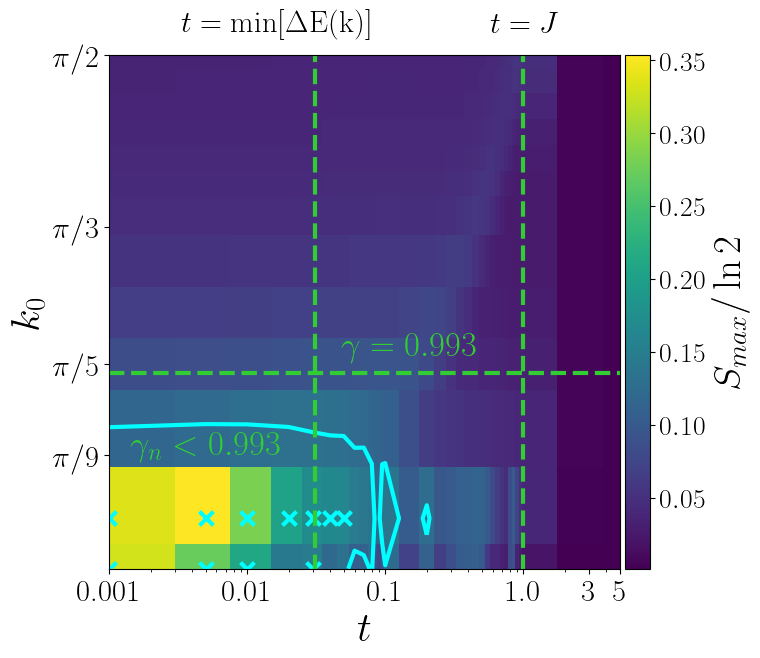

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(bwidth+1,bwidth))

vg_array = S_df.index
t_array = S_df.columns
#im = ax.contourf(t_array, vg_array, S_df.values,levels=8, cmap="viridis")
im = ax.pcolormesh(t_array, vg_array, B_df.values, cmap="viridis", shading='auto')

plt.contour(purity_pivot.columns, purity_pivot.index, purity_pivot.values, 
           levels=[0.993], colors='cyan', linewidths=3)

plt.scatter(boundary_points["t"], boundary_points["K0"], 
           color='cyan', s=100, marker='x', linewidth=3)
# lines from perturbation theory
ax.vlines([np.pi/(LL+1), J], ymin=0.0*np.pi/2, ymax=np.pi/2, color='limegreen', lw=3, linestyle="dashed", clip_on=False)  # tick-like line

# Purity according to von Neuman
n_ = 6 # this is the scaling
K0_ = 2*n_*Om_
R2 = np.exp(-(2*Om_/K0_)**2)
purity = 0.5*( 1+ R2*np.sin(af)**2 +np.cos(af)**2 )

ax.axhline(K0_, color='limegreen', lw=3, linestyle="dashed", clip_on=False)  # horizontal line at 2*Omega

# get axis scale and ticks
plt.xscale('log')
ax.set_xlim(0.001, 5)
ax.set_ylim(min(K0_unique), max(K0_unique))
ax.set_xticks( [0.001, 0.01,0.1,1.0,3, 5], [0.001, 0.01,0.1,1.0,3,5] ,fontsize=22)
ax.set_yticks( [np.pi/9,np.pi/5,np.pi/3,np.pi/2], labels=[r"$\pi/9$",r"$\pi/5$",r"$\pi/3$",r"$\pi/2$"],fontsize=22 )

# anotate a bit 
ax.annotate(r"$\gamma = {0:.3f}$".format(purity), xy=(0.15, K0_), 
            xytext=(0.15, K0_+0.05),ha='center', c="limegreen", fontsize= 25,fontweight='bold')

ax.annotate(r"$\gamma_n < {0:.3f}$".format(purity), xy=(0.001, np.pi/9), 
            xytext=(0.005, np.pi/9),ha='center', c="limegreen", fontsize= 25,fontweight='bold')

y_tick = np.pi/2
ax.annotate(
    r'$t=\rm{min}[ \Delta E(k)]$', 
    xy=(np.pi/(LL+1), y_tick), 
    xytext=(np.pi/(LL+1) - 0.015, y_tick + 0.07), fontsize=22,ha='center')
ax.annotate(
    r'$t=J$', 
    xy=(J, y_tick), 
    xytext=(J, y_tick + 0.07), fontsize=22,ha='center')
# set up color bar
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
cbar = fig.colorbar(im, cax, shrink=0.9)   
cbar.ax.set_ylabel(r'$S_{max}/\ln{2}$', rotation=90, fontsize=28)

ax.set_ylabel(r"$k_0$",fontweight='bold',fontsize=30)
ax.set_xlabel(r"$t$",fontweight='bold',fontsize=30)

plt.tight_layout()